### Metrics definitions (standardized)
- **net_pct**: Mean signed next-day percent per trade across BUY *and* SELL, where SELL returns are sign-flipped so that good decisions are positive. (Mean of `net_component_from_prev`.)
- **realized_pct**: **TOTAL compounded percent** across all BUY trades for the symbol: `100 * (prod_i (1 + today_vs_prev_pct_i/100) - 1)`.


In [85]:
# Cell 1 — Imports & configuration
import re
from pathlib import Path
from typing import Dict, List, Tuple, Optional
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from __future__ import annotations
import json

# ==== CONFIG ====
DATA_DIR = Path(r"C:\Users\brobi\OneDrive\Desktop\Algo1\logs")          # change to your folder
CSV_GLOB = "infer_*.csv"           # your strict pattern
OUT_DIR  = Path("./trade_tracking")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Commissions/slippage (set to 0 for now)
COMMISSION_PER_TRADE = 0.10
SLIPPAGE_BPS = 10  # 10 = 0.10%; price is adjusted by (1±bps/10000) on executions

# Starting capital per symbol
INITIAL_STOCK_USD = 100.0  # immediately invested on first day
INITIAL_CASH_USD  = 100.0  # reserved as starting cash


print('hello world')

hello world


In [86]:
# Cell 2 — Load CSVs (strict filename date extractor)
DATE_PATTERN = re.compile(r"^infer_(\d{4}-\d{2}-\d{2})$", re.IGNORECASE)

def extract_date_from_name(name: str) -> str | None:
    stem = Path(name).stem  # drops .csv
    m = DATE_PATTERN.match(stem)
    return m.group(1) if m else None

def load_one_csv(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    # Parse & coerce
    if "timestamp_utc" in df.columns:
        df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True, errors="coerce")
    if "date_bar" in df.columns:
        df["date_bar"] = df["date_bar"].astype(str)
    # numeric
    for col in ["price","buf_scale",
                "pos_frac","pre_sig","sig","mid","upper","lower"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    # text
    for col in ["symbol","bias","side"]:
        if col in df.columns:
            df[col] = df[col].astype("string")
    return df

def load_all(data_dir: Path, csv_glob: str="infer_*.csv") -> Dict[str, pd.DataFrame]:
    out: Dict[str, pd.DataFrame] = {}
    files = sorted(data_dir.glob(csv_glob))
    if not files:
        print(f"No CSVs in {data_dir} with pattern {csv_glob}.")
        return out
    for f in files:
        d = extract_date_from_name(f.name)
        if not d:
            print(f"[skip] no date in {f.name}")
            continue
        df = load_one_csv(f).copy()
        df.insert(0, "file_date", d)
        out[d] = df
        print(f"Loaded {f.name} -> date={d}, rows={len(df)}")
    return out

dfs_by_date = load_all(DATA_DIR, CSV_GLOB)
if dfs_by_date:
    all_df = pd.concat(dfs_by_date.values(), ignore_index=True)
    # Ensure required columns exist
    required = {"symbol","date_bar","price","side","pos_frac"}
    missing = required - set(all_df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}")
    # Normalize
    all_df["symbol"] = all_df["symbol"].str.upper()
    all_df["side"] = all_df["side"].str.upper().str.strip()
    all_df["pos_frac"] = all_df["pos_frac"].clip(lower=0, upper=1)
    # Ensure one row per symbol/day (if duplicates exist, keep last)
    all_df = (all_df
              .sort_values(["symbol","date_bar","timestamp_utc"], na_position="last")
              .drop_duplicates(subset=["symbol","date_bar"], keep="last"))
    # Sort for simulation
    all_df = all_df.sort_values(["symbol","date_bar"]).reset_index(drop=True)
else:
    all_df = pd.DataFrame()
all_df.head()


Loaded infer_2025-09-15.csv -> date=2025-09-15, rows=38
Loaded infer_2025-09-16.csv -> date=2025-09-16, rows=38
Loaded infer_2025-09-18.csv -> date=2025-09-18, rows=19
Loaded infer_2025-09-19.csv -> date=2025-09-19, rows=18
Loaded infer_2025-09-22.csv -> date=2025-09-22, rows=19
Loaded infer_2025-09-23.csv -> date=2025-09-23, rows=19
Loaded infer_2025-09-24.csv -> date=2025-09-24, rows=19
Loaded infer_2025-09-25.csv -> date=2025-09-25, rows=19
Loaded infer_2025-09-26.csv -> date=2025-09-26, rows=19
Loaded infer_2025-09-29.csv -> date=2025-09-29, rows=19
Loaded infer_2025-09-30.csv -> date=2025-09-30, rows=19
Loaded infer_2025-10-01.csv -> date=2025-10-01, rows=19
Loaded infer_2025-10-02.csv -> date=2025-10-02, rows=24
Loaded infer_2025-10-03.csv -> date=2025-10-03, rows=24
Loaded infer_2025-10-06.csv -> date=2025-10-06, rows=24
Loaded infer_2025-10-07.csv -> date=2025-10-07, rows=24
Loaded infer_2025-10-08.csv -> date=2025-10-08, rows=24
Loaded infer_2025-10-09.csv -> date=2025-10-09, 

,file_date,timestamp_utc,symbol,price_3pm,signal,pos_frac,qty,bias,buf_scale,mid,...,lower,date_bar,price,pre_sig,sig,side,profile,exp_id,model_source,model_path
0,2025-10-20,2025-10-21 02:56:29+00:00,AAPL,NaN,NaN,0.3,NaN,revert,0.8,238.162439,...,235.622816,2025-10-20,262.245,0.0,0.0,SELL,prod,NaN,legacy_prefix,models\dqn_sy_AAPL.pt
1,2025-10-21,2025-10-22 00:10:22+00:00,AAPL,NaN,NaN,0.2,NaN,revert,1.2,238.866179,...,235.047049,2025-10-21,262.730,0.0,0.0,SELL,prod,NaN,legacy_prefix,models\dqn_sy_AAPL.pt
2,2025-10-22,2025-10-22 18:47:49+00:00,AAPL,NaN,NaN,0.2,NaN,revert,1.2,238.712986,...,234.621123,2025-10-22,256.860,0.0,0.0,SELL,prod,NaN,legacy_prefix,models\dqn_sy_AAPL.pt
3,2025-10-23,2025-10-23 18:21:28+00:00,AAPL,NaN,NaN,0.4,NaN,trend,1.2,239.473178,...,235.485372,2025-10-23,259.990,1.0,1.0,BUY,prod,NaN,legacy_prefix,models\dqn_sy_AAPL.pt
4,2025-10-24,2025-10-25 20:30:56+00:00,AAPL,NaN,NaN,0.2,NaN,revert,1.0,239.723419,...,236.345724,2025-10-24,262.780,0.0,0.0,SELL,prod,NaN,legacy_prefix,models\dqn_sy_AAPL.pt


In [87]:
# Cell 3 — Simulator utilities

def apply_slippage(price: float, side: str, bps: float) -> float:
    """Adjust execution price by slippage (bps). BUY -> worse (higher), SELL -> worse (lower)."""
    if bps <= 0:
        return price
    mult = (1 + bps/10000.0) if side == "BUY" else (1 - bps/10000.0)
    return price * mult

def execute_buy(cash: float, shares: float, price: float, pos_frac: float) -> Tuple[float,float,float]:
    """Spend pos_frac of *available cash* to buy shares."""
    to_spend = max(0.0, pos_frac) * cash
    if to_spend <= 0:
        return cash, shares, 0.0
    exec_price = apply_slippage(price, "BUY", SLIPPAGE_BPS)
    qty = to_spend / exec_price if exec_price > 0 else 0.0
    if qty <= 0:
        return cash, shares, 0.0
    # apply commission
    cash_after = cash - (qty * exec_price) - COMMISSION_PER_TRADE
    if cash_after < -1e-9:
        # edge guard: never go negative; scale down
        scale = (cash - COMMISSION_PER_TRADE) / max(qty * exec_price, 1e-12)
        qty *= max(scale, 0)
        cash_after = cash - (qty * exec_price) - COMMISSION_PER_TRADE
    return cash_after, shares + qty, qty

def execute_sell(cash: float, shares: float, price: float, pos_frac: float) -> Tuple[float,float,float]:
    """Sell pos_frac of current shares."""
    qty = max(0.0, pos_frac) * shares
    if qty <= 0:
        return cash, shares, 0.0
    exec_price = apply_slippage(price, "SELL", SLIPPAGE_BPS)
    proceeds = qty * exec_price
    cash_after = cash + proceeds - COMMISSION_PER_TRADE
    shares_after = shares - qty
    # numerical guard
    if shares_after < 0:
        shares_after = 0.0
    return cash_after, shares_after, qty


In [88]:
#cell 4
def simulate_symbol(df_sym: pd.DataFrame) -> pd.DataFrame:
    """
    Assumptions:
      - On the first trading day, you ALREADY hold $100 worth of shares (INITIAL_STOCK_USD)
        and ALSO have $100 in cash (INITIAL_CASH_USD).
      - Daily:
          BUY  -> spend (pos_frac * current_cash)
          SELL -> sell (pos_frac * current_shares)
          HOLD -> do nothing
      - No leverage; cash cannot go negative.
    Returns a daily ledger with:
      date, price, side, pos_frac, cash, shares, portfolio_value, buy_qty, sell_qty, baseline_value
    """
    sym = df_sym["symbol"].iloc[0]
    if "date" not in df_sym.columns and "date_bar" in df_sym.columns:
        df_sym = df_sym.rename(columns={"date_bar": "date"})
    df_sym = df_sym.sort_values("date").reset_index(drop=True).copy()

    df_sym["price"] = pd.to_numeric(df_sym["price"], errors="coerce").fillna(method="ffill")
    if df_sym["price"].isna().any():
        df_sym["price"] = df_sym["price"].fillna(0.0)

    first_price = float(df_sym["price"].iloc[0])
    init_shares = (INITIAL_STOCK_USD / first_price) if first_price > 0 else 0.0
    cash = float(INITIAL_CASH_USD)
    shares = float(init_shares)

    rows = []
    for _, r in df_sym.iterrows():
        d = r["date"]
        px = float(r["price"])
        side = (r["side"] or "").upper()
        frac = float(r["pos_frac"]) if pd.notna(r["pos_frac"]) else 0.0

        buy_qty = 0.0
        sell_qty = 0.0

        if side == "BUY" and frac > 0:
            cash, shares, buy_qty = execute_buy(cash, shares, px, frac)
        elif side == "SELL" and frac > 0:
            cash, shares, sell_qty = execute_sell(cash, shares, px, frac)
        # HOLD -> nothing

        port = cash + shares * px
        baseline_value = init_shares * px  # "untouched" $100 stock baseline

        rows.append({
            "symbol": sym,
            "date": d,
            "price": px,
            "side": side,
            "pos_frac": frac,
            "cash": cash,
            "shares": shares,
            "portfolio_value": port,
            "buy_qty": buy_qty,
            "sell_qty": sell_qty,
            "baseline_value": baseline_value
        })
    return pd.DataFrame(rows)


In [89]:
# Cell 5 — Run simulation for all symbols + full & filtered analyses


# ========= Configure an optional subset =========
# Leave empty [] to analyze all symbols only.
SYMBOL_FILTER = ["AI", "AMD"]   # <-- edit this list as you like

# ---- 1) Choose the source DF ----
if "all_df" in globals() and isinstance(all_df, pd.DataFrame) and not all_df.empty:
    src = all_df.copy()
elif "loaded_logs" in globals() and isinstance(loaded_logs, pd.DataFrame) and not loaded_logs.empty:
    # from the robust loader cell
    src = loaded_logs.copy()
else:
    raise SystemExit("No data loaded; ensure all_df or loaded_logs is populated upstream.")

# ---- 2) Normalize columns ----
cols_lower = {c.lower(): c for c in src.columns}

def first_present(*cands):
    for c in cands:
        if c in cols_lower:
            return cols_lower[c]
    return None

sym_col   = first_present("symbol","ticker","sym","stock","secid")
date_col  = first_present("date_bar","date","day","ts","timestamp","timestamp_utc","file_date")
price_col = first_present("price","price_3pm","close","last","px","close_price","close_px","mid")
side_col  = first_present("side","signal","action","decision","target_action","recommendation","call","sig","pre_sig")
pf_col    = first_present("pos_frac","posfrac","position_frac","position_fraction","weight","weight_frac")

missing = [name for name, col in {
    "symbol": sym_col, "date": date_col, "price": price_col, "side/signal": side_col, "pos_frac": pf_col
}.items() if col is None]
if missing:
    raise SystemExit(f"Missing required columns (or variants): {missing}. "
                     f"Available columns: {list(src.columns)}")

df = src[[sym_col, date_col, price_col, side_col, pf_col]].copy()
df.columns = ["symbol","date","price","side","pos_frac"]

# ---- 3) Clean types & values ----
df["price"] = pd.to_numeric(df["price"], errors="coerce")
df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.normalize()
df["side"] = df["side"].astype(str).str.upper().str.strip()
df.loc[df["side"].isin(["BUY","LONG","B"]), "side"] = "BUY"
df.loc[df["side"].isin(["SELL","SHORT","S"]), "side"] = "SELL"
df.loc[df["side"].isin(["HOLD","NONE","NEUTRAL","0","NA","NAN"]), "side"] = "HOLD"
df["pos_frac"] = pd.to_numeric(df["pos_frac"], errors="coerce")

pre_rows = len(df)
df = df.dropna(subset=["symbol","date","price","side"])
require_pos_frac = False  # set True if simulate_symbol strictly needs pos_frac
if require_pos_frac:
    df = df.dropna(subset=["pos_frac"])
else:
    df["pos_frac"] = df["pos_frac"].fillna(1.0)

df = df.sort_values(["symbol","date"]).drop_duplicates(["symbol","date"], keep="last")

if df.empty:
    raise SystemExit("After normalization/cleaning, there are no rows to simulate/analyze.")

# ------------------ (A) Your original simulation loop (unchanged) ------------------
symbols = sorted(df["symbol"].dropna().unique())
print(f"Simulating {len(symbols)} symbols")

ledgers: Dict[str, pd.DataFrame] = {}
processed, skipped = 0, 0
reasons = []

for s in symbols:
    d = df.loc[df["symbol"] == s, ["symbol","date","price","side","pos_frac"]].copy()

    rs = []
    if d["price"].isna().all():
        rs.append("all prices NaN")
    if d["date"].isna().all():
        rs.append("all dates NaN")
    if d["side"].isin(["BUY","SELL","HOLD"]).sum() == 0:
        rs.append("no recognizable side/signal values")
    if require_pos_frac and d["pos_frac"].isna().all():
        rs.append("pos_frac all NaN (required)")

    allow_ffill_price = False
    if allow_ffill_price:
        d["price"] = d["price"].ffill()

    d = d.dropna(subset=["date","price"])
    if d.empty:
        rs.append("no usable rows after cleaning")

    if rs:
        skipped += 1
        reasons.append((s, "; ".join(rs)))
        continue

    df_sym = d.rename(columns={"date":"date_bar"})[["symbol","date_bar","price","side","pos_frac"]]

    try:
        ledger = simulate_symbol(df_sym)
        ledgers[s] = ledger
        processed += 1
        (OUT_DIR / f"{s}_daily_ledger.csv").parent.mkdir(parents=True, exist_ok=True)
        ledger.to_csv(OUT_DIR / f"{s}_daily_ledger.csv", index=False)
    except Exception as e:
        skipped += 1
        reasons.append((s, f"simulate_symbol error: {type(e).__name__}: {e}"))

print(f"Finished. Processed={processed}, Skipped={skipped}")
if reasons:
    print("Skip reasons:")
    for sym, r in reasons[:50]:
        print(f"  - {sym}: {r}")
    if len(reasons) > 50:
        print(f"  ... and {len(reasons)-50} more")

if ledgers:
    combined = pd.concat(ledgers.values(), ignore_index=True, sort=False)
    combined_path = OUT_DIR / "all_symbols_daily_ledger.csv"
    combined.to_csv(combined_path, index=False)
    print(f"Saved combined ledger → {combined_path}")

# ------------------ (B) Full-portfolio & filtered analyses ------------------

def tag_outcome(signal: str, pct_change: float) -> Optional[str]:
    if signal == "HOLD":
        return None
    if signal == "BUY":
        return "WIN" if pct_change > 0 else ("LOSS" if pct_change < 0 else "NEUTRAL")
    if signal == "SELL":
        return "WIN" if pct_change < 0 else ("LOSS" if pct_change > 0 else "NEUTRAL")
    return None

def signed_return_for_net(signal: str, pct_change: float) -> Optional[float]:
    if signal == "HOLD":
        return None
    if pct_change == 0:
        return 0.0
    if signal == "BUY":
        return pct_change if pct_change > 0 else -abs(pct_change)
    if signal == "SELL":
        return -pct_change if pct_change > 0 else abs(pct_change)
    return None

def compute_pct_changes(g: pd.DataFrame) -> pd.DataFrame:
    g = g.sort_values("date").reset_index(drop=True)
    g["prev_date"]    = g["date"].shift(1)
    g["prev_signal"]  = g["side"].shift(1)
    g["prev_price"]   = g["price"].shift(1)
    g["prev_pos_frac"]= g["pos_frac"].shift(1)
    g["next_price"]   = g["price"].shift(-1)
    g["next_date"]    = g["date"].shift(-1)

    g["today_vs_prev_pct"] = (g["price"] / g["prev_price"] - 1.0) * 100.0
    g["next_day_pct"]      = (g["next_price"] / g["price"] - 1.0) * 100.0

    g["outcome_from_prev"] = g.apply(
        lambda r: tag_outcome(str(r["prev_signal"]) if pd.notna(r["prev_signal"]) else "HOLD",
                              float(r["today_vs_prev_pct"]) if pd.notna(r["today_vs_prev_pct"]) else 0.0),
        axis=1
    )
    g["outcome_from_today"] = g.apply(
        lambda r: tag_outcome(str(r["side"]),
                              float(r["next_day_pct"]) if pd.notna(r["next_day_pct"]) else 0.0),
        axis=1
    )
    g["net_component_from_prev"] = g.apply(
        lambda r: signed_return_for_net(str(r["prev_signal"]) if pd.notna(r["prev_signal"]) else "HOLD",
                                        float(r["today_vs_prev_pct"]) if pd.notna(r["today_vs_prev_pct"]) else 0.0),
        axis=1
    )
    return g

def _safe_mean(s: pd.Series) -> float:
    s = s.dropna()
    return float(s.mean()) if len(s) else 0.0

def _realized_mean(df_: pd.DataFrame) -> float:
    # Only prior BUY exposure contributes (SELL flattens)
    s = df_.loc[df_["prev_signal"] == "BUY", "net_component_from_prev"].dropna()
    return float(s.mean()) if len(s) else 0.0

def run_analysis_for(df_in: pd.DataFrame, label: str) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Returns: summary (realized), details, summary_by_exec, sym_week_exec, sym_all_exec, overall_all_exec
       Also saves CSVs using DATA_DIR (if defined) else current dir, with filenames prefixed by the label.
    """
    assert not df_in.empty, f"{label}: empty input"

    details = df_in.groupby("symbol", group_keys=False).apply(compute_pct_changes)
    valid = details[pd.notna(details["prev_date"])].copy()
    valid["is_trade"] = valid["outcome_from_prev"].isin(["WIN","LOSS","NEUTRAL"])
    valid["is_win"]   = valid["outcome_from_prev"].eq("WIN")
    valid["is_loss"]  = valid["outcome_from_prev"].eq("LOSS")

    # daily summary (realized on current day)
    agg = valid.groupby("date").agg(
        symbols=("symbol","nunique"),
        trades=("is_trade","sum"),
        wins=("is_win","sum"),
        losses=("is_loss","sum"),
        net_pct=("net_component_from_prev", _safe_mean),
    ).reset_index()
    agg["win_pct"]  = (agg["wins"]   / agg["trades"]).fillna(0) * 100.0
    agg["loss_pct"] = (agg["losses"] / agg["trades"]).fillna(0) * 100.0
    per_day_realized = valid.groupby("date").apply(_realized_mean).rename("realized_pct").reset_index()
    summary = agg.merge(per_day_realized, on="date", how="left").sort_values("date")

    # execution-aligned
    valid["exec_date"] = pd.to_datetime(valid["prev_date"]).dt.normalize()
    agg_exec = valid.groupby("exec_date").agg(
        symbols=("symbol","nunique"),
        trades=("is_trade","sum"),
        wins=("is_win","sum"),
        losses=("is_loss","sum"),
        net_pct=("net_component_from_prev", _safe_mean),
    ).reset_index()
    agg_exec["win_pct"]  = (agg_exec["wins"]   / agg_exec["trades"]).fillna(0) * 100.0
    agg_exec["loss_pct"] = (agg_exec["losses"] / agg_exec["trades"]).fillna(0) * 100.0
    per_day_realized_exec = valid.groupby("exec_date").apply(_realized_mean).rename("realized_pct").reset_index()
    summary_by_exec = agg_exec.merge(per_day_realized_exec, on="exec_date", how="left").sort_values("exec_date")

    # weekly & all-time (execution-aligned)
    valid["week_start_exec"] = valid["exec_date"].dt.to_period("W-MON").dt.start_time.dt.normalize()
    sym_week_exec = (
        valid.groupby(["symbol","week_start_exec"])
             .apply(lambda g: pd.Series({
                 "start_date": g["exec_date"].min(),
                 "end_date":   g["exec_date"].max(),
                 "trades":     int(g["is_trade"].sum()),
                 "wins":       int(g["is_win"].sum()),
                 "losses":     int(g["is_loss"].sum()),
                 "win_pct":    (g["is_win"].sum() / max(g["is_trade"].sum(), 1)) * 100.0,
                 "loss_pct":   (g["is_loss"].sum() / max(g["is_trade"].sum(), 1)) * 100.0,
                 "net_pct":    _safe_mean(g["net_component_from_prev"]),
                 "realized_pct": _realized_mean(g),
             }))
             .reset_index()
             .sort_values(["symbol","week_start_exec"])
    )
    sym_all_exec = (
        valid.groupby("symbol")
             .apply(lambda g: pd.Series({
                 "first_exec_date": g["exec_date"].min(),
                 "last_exec_date":  g["exec_date"].max(),
                 "trades":     int(g["is_trade"].sum()),
                 "wins":       int(g["is_win"].sum()),
                 "losses":     int(g["is_loss"].sum()),
                 "win_pct":    (g["is_win"].sum() / max(g["is_trade"].sum(), 1)) * 100.0,
                 "loss_pct":   (g["is_loss"].sum() / max(g["is_trade"].sum(), 1)) * 100.0,
                 "net_pct":    _safe_mean(g["net_component_from_prev"]),
                 "realized_pct": _realized_mean(g),
             }))
             .reset_index()
             .sort_values(["symbol"])
    )
    overall_all_exec = pd.DataFrame([{
        "first_exec_date": valid["exec_date"].min(),
        "last_exec_date":  valid["exec_date"].max(),
        "trades":     int(valid["is_trade"].sum()),
        "wins":       int(valid["is_win"].sum()),
        "losses":     int(valid["is_loss"].sum()),
        "win_pct":    (valid["is_win"].sum() / max(valid["is_trade"].sum(), 1)) * 100.0,
        "loss_pct":   (valid["is_loss"].sum() / max(valid["is_trade"].sum(), 1)) * 100.0,
        "net_pct":    _safe_mean(valid["net_component_from_prev"]),
        "realized_pct": _realized_mean(valid),
    }])

    # Save with label prefix
    from pathlib import Path
    try:
        out_dir = DATA_DIR
    except NameError:
        out_dir = Path(".")
    out_dir = Path(out_dir)

    def p(name): return out_dir / f"{label}_{name}.csv"

    summary.to_csv(p("daily_breakdown_summary"), index=False)
    details.to_csv(p("daily_breakdown_details"), index=False)
    summary_by_exec.to_csv(p("daily_breakdown_summary_by_execdate"), index=False)
    sym_week_exec.to_csv(p("per_symbol_weekly_summary_by_execdate"), index=False)
    sym_all_exec.to_csv(p("per_symbol_alltime_summary_by_execdate"), index=False)
    overall_all_exec.to_csv(p("overall_alltime_summary_by_execdate"), index=False)

    print(f"[{label}] saved →", p("daily_breakdown_summary"))
    return summary, details, summary_by_exec, sym_week_exec, sym_all_exec, overall_all_exec

# ---- Run analysis for FULL portfolio ----
summary_full, details_full, summary_by_exec_full, sym_week_full, sym_all_full, overall_full = run_analysis_for(df, "full")

# ---- Run analysis for FILTERED subset (if configured) ----
if SYMBOL_FILTER:
    df_sub = df[df["symbol"].isin([s.upper() for s in SYMBOL_FILTER])].copy()
    if df_sub.empty:
        print(f"[filtered] No rows matched SYMBOL_FILTER={SYMBOL_FILTER}")
    else:
        summary_f, details_f, summary_by_exec_f, sym_week_f, sym_all_f, overall_f = run_analysis_for(df_sub, "filtered")
        # quick peek
        print("\n=== Filtered summary (tail) ===")
        display(summary_f.tail(10))
else:
    print("[filtered] SYMBOL_FILTER empty; skipped filtered run.")

print("\n=== Full portfolio summary (tail) ===")
display(summary_full.tail(10))


Simulating 62 symbols


C:\Users\brobi\AppData\Local\Temp\ipykernel_15324\3788012946.py:20: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_sym["price"] = pd.to_numeric(df_sym["price"], errors="coerce").fillna(method="ffill")
C:\Users\brobi\AppData\Local\Temp\ipykernel_15324\3788012946.py:20: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_sym["price"] = pd.to_numeric(df_sym["price"], errors="coerce").fillna(method="ffill")
C:\Users\brobi\AppData\Local\Temp\ipykernel_15324\3788012946.py:20: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_sym["price"] = pd.to_numeric(df_sym["price"], errors="coerce").fillna(method="ffill")
C:\Users\brobi\AppData\Local\Temp\ipykernel_15324\3788012946.py:20: FutureWarning: Series.fillna with 'method' is deprecated

Finished. Processed=62, Skipped=0
Saved combined ledger → trade_tracking\all_symbols_daily_ledger.csv


C:\Users\brobi\AppData\Local\Temp\ipykernel_15324\2663791957.py:206: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_day_realized = valid.groupby("date").apply(_realized_mean).rename("realized_pct").reset_index()
C:\Users\brobi\AppData\Local\Temp\ipykernel_15324\2663791957.py:220: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_day_realized_exec = valid.groupby("exec_date").apply(_realized_mean).rename("realized_

[full] saved → C:\Users\brobi\OneDrive\Desktop\Algo1\logs\full_daily_breakdown_summary.csv
[filtered] saved → C:\Users\brobi\OneDrive\Desktop\Algo1\logs\filtered_daily_breakdown_summary.csv

=== Filtered summary (tail) ===


C:\Users\brobi\AppData\Local\Temp\ipykernel_15324\2663791957.py:227: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
C:\Users\brobi\AppData\Local\Temp\ipykernel_15324\2663791957.py:243: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
C:\Users\brobi\AppData\Local\Temp\ipykernel_15324\2663791957.py:190: FutureWarning: DataFrameGroupBy.apply operated on the grouping 

,date,symbols,trades,wins,losses,net_pct,win_pct,loss_pct,realized_pct
14,2025-10-13,2,2,1,1,-3.064073,50.0,50.0,0.000000
15,2025-10-14,2,2,0,2,-2.164720,0.0,100.0,0.000000
16,2025-10-15,2,2,1,1,-3.135027,50.0,50.0,0.000000
17,2025-10-16,2,2,2,0,3.844913,100.0,0.0,0.000000
18,2025-10-17,2,2,2,0,1.311817,100.0,0.0,0.000000
19,2025-10-20,2,2,0,2,-3.678157,0.0,100.0,0.000000
20,2025-10-21,2,2,2,0,1.046801,100.0,0.0,0.000000
21,2025-10-22,2,2,2,0,4.508628,100.0,0.0,0.000000
22,2025-10-23,2,2,1,1,0.069700,50.0,50.0,3.366906
23,2025-10-24,2,2,1,1,-3.499041,50.0,50.0,0.000000



=== Full portfolio summary (tail) ===


,date,symbols,trades,wins,losses,net_pct,win_pct,loss_pct,realized_pct
14,2025-10-13,24,20,6,14,-5.672378,30.000000,70.000000,-3.164744
15,2025-10-14,24,21,9,12,0.723198,42.857143,57.142857,1.553476
16,2025-10-15,37,33,16,17,0.520840,48.484848,51.515152,2.432830
17,2025-10-16,37,33,22,10,1.704977,66.666667,30.303030,-3.556523
18,2025-10-17,37,30,20,10,0.682395,66.666667,33.333333,-1.265004
19,2025-10-20,37,33,18,15,5.204783,54.545455,45.454545,14.629154
20,2025-10-21,62,56,30,26,2.164513,53.571429,46.428571,3.495354
21,2025-10-22,62,58,33,25,0.450736,56.896552,43.103448,-4.429704
22,2025-10-23,62,52,27,24,0.771735,51.923077,46.153846,3.753450
23,2025-10-24,62,55,29,26,-0.183913,52.727273,47.272727,2.936090


In [90]:
#cell 5.5
# Build and save an overall portfolio curve (sum across symbols)
def build_portfolio_summary(ledgers: dict[str, pd.DataFrame]) -> pd.DataFrame:
    # Collect all dates across symbols
    all_dates = sorted({
        pd.to_datetime(d, errors="coerce").date()
        for df in ledgers.values()
        for d in df["date"]
    })
    if not all_dates:
        return pd.DataFrame()

    # Sum per-symbol portfolio_value over a common date index (forward-fill gaps)
    idx = pd.to_datetime(pd.Series(all_dates))
    total_series = None
    base_series = None

    for sym, df in ledgers.items():
        tmp = df.copy()
        tmp["date"] = pd.to_datetime(tmp["date"], errors="coerce")
        tmp = tmp.sort_values("date")
        # Reindex to global date index (as daily frequency of actual dates present)
        s_port = tmp.set_index("date")["portfolio_value"].reindex(idx).ffill()
        s_base  = tmp.set_index("date")["baseline_value"].reindex(idx).ffill()

        total_series = s_port if total_series is None else (total_series.add(s_port, fill_value=0.0))
        base_series  = s_base  if base_series  is None else (base_series.add(s_base,  fill_value=0.0))

    out = pd.DataFrame({
        "date": idx,
        "total_portfolio_value": total_series.values,
        "total_baseline_value": base_series.values  # optional (handy for comparison)
    })
    return out

def plot_portfolio_summary(summary_df: pd.DataFrame, out_path: Path):
    if summary_df.empty:
        print("No data for portfolio summary.")
        return
    df = summary_df.copy().sort_values("date")

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.set_title("All-Symbol Portfolio Value (cash + stock)")
    ax.plot(df["date"], df["total_portfolio_value"], label="Total Portfolio", color="tab:blue")
    ax.plot(df["date"], df["total_baseline_value"], label="Total Buy & Hold", color="tab:green", linestyle="--")
    ax.set_ylabel("Value ($)")
    ax.legend(loc="upper left")
    fig.tight_layout()
    fig.savefig(out_path, dpi=150)
    plt.close(fig)

# Build & save
summary_df = build_portfolio_summary(ledgers)
plot_portfolio_summary(summary_df, OUT_DIR / "portfolio_summary.png")
print(f"Saved overall summary plot to: {OUT_DIR / 'portfolio_summary.png'}")


Saved overall summary plot to: trade_tracking\portfolio_summary.png


In [91]:
# Cell 6 — Plotting per symbol
def plot_symbol(ledger: pd.DataFrame, out_path: Path):
    """
    Plot per symbol:
      - Portfolio Value (cash + shares*price)
      - Price
      - Buy-and-hold Baseline (initial $100 in stock, untouched)
      - Buy/Sell markers on the price
    Colors: distinct for each line/marker.
    """
    if ledger.empty:
        return
    df = ledger.copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df = df.sort_values("date")

    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax1.set_title(f"{df['symbol'].iloc[0]} — Portfolio vs Price")
    # Distinct colors
    ax1.plot(df["date"], df["portfolio_value"], label="Portfolio Value", color="tab:blue")
    ax1.plot(df["date"], df["baseline_value"], label="Buy & Hold ($100 stock)", color="tab:green", linestyle="--")
    ax1.set_ylabel("Portfolio / Baseline ($)")

    ax2 = ax1.twinx()
    ax2.plot(df["date"], df["price"], label="Price", color="tab:orange")
    ax2.set_ylabel("Price ($)")

    # Buy/Sell markers on price
    buys = df[df["buy_qty"] > 0]
    sells = df[df["sell_qty"] > 0]
    ax2.scatter(buys["date"], buys["price"], marker="^", s=60, label="BUY", color="tab:green", zorder=5)
    ax2.scatter(sells["date"], sells["price"], marker="v", s=60, label="SELL", color="tab:red", zorder=5)

    # Combined legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

    fig.tight_layout()
    fig.savefig(out_path, dpi=140)
    plt.close(fig)



In [92]:
#Cell 6.5 call plot_symbol
# Generate and save per-symbol plots
n = 0
for s, ledger in ledgers.items():
    out_path = OUT_DIR / f"{s}_tracking.png"
    plot_symbol(ledger, out_path)
    n += 1
print(f"Saved {n} symbol plots to: {OUT_DIR.resolve()}")


Saved 62 symbol plots to: C:\Users\brobi\OneDrive\Desktop\Algo1\logs\trade_tracking


In [93]:
# Cell 7 — Save outputs (optional)
# Save the combined DataFrame as a CSV / Parquet for downstream use
if all_df is not None:
    out_csv = DATA_DIR / "_combined_all.csv"
    all_df.to_csv(out_csv, index=False)
    print(f"Saved combined CSV → {out_csv}")

    try:
        import pyarrow  # noqa: F401
        out_parquet = DATA_DIR / "_combined_all.parquet"
        all_df.to_parquet(out_parquet, index=False)
        print(f"Saved combined Parquet → {out_parquet}")
    except Exception as e:
        print("Parquet save skipped (pyarrow not installed):", e)


Saved combined CSV → C:\Users\brobi\OneDrive\Desktop\Algo1\logs\_combined_all.csv
Saved combined Parquet → C:\Users\brobi\OneDrive\Desktop\Algo1\logs\_combined_all.parquet


In [94]:
# === Cell 7 — Normalize and save the combined table ===
import pandas as pd
import numpy as np

assert all_df is not None and not all_df.empty, "Expected all_df to be populated earlier."

df = all_df.copy()

# --- 1) Choose canonical columns ---
# symbol
if "symbol" not in df.columns:
    raise SystemExit(f"'symbol' column missing. Available: {list(df.columns)}")

# date
date_col = None
for c in ["date_bar", "file_date", "date", "timestamp_utc"]:
    if c in df.columns:
        date_col = c
        break
if date_col is None:
    raise SystemExit("No date-like column found (looked for date_bar/file_date/date/timestamp_utc).")

# price
price_col = None
for c in ["price", "price_3pm", "close", "last", "mid", "upper", "lower"]:
    if c in df.columns:
        price_col = c
        break
if price_col is None:
    raise SystemExit("No price-like column found (looked for price/price_3pm/close/last/mid/upper/lower).")

# side/signal
side_col = None
for c in ["side", "signal", "sig", "pre_sig"]:
    if c in df.columns:
        side_col = c
        break

# pos_frac (optional)
posf_col = "pos_frac" if "pos_frac" in df.columns else None

# --- 2) Build normalized frame ---
norm = pd.DataFrame({
    "symbol": df["symbol"].astype(str).str.upper().str.strip(),
    "date_bar": pd.to_datetime(df[date_col], errors="coerce")
})

# If timestamp_utc was picked, drop time to date to align with daily bars
norm["date_bar"] = norm["date_bar"].dt.normalize()

# Price numeric
norm["price"] = pd.to_numeric(df[price_col], errors="coerce")

# Side normalization (BUY/SELL/HOLD); if we only have 'sig' or 'pre_sig', treat them the same
def _norm_side(x):
    x = str(x).upper().strip()
    if x in {"BUY", "LONG", "B"}: return "BUY"
    if x in {"SELL", "SHORT", "S"}: return "SELL"
    if x in {"HOLD", "NONE", "NEUTRAL", "0", "NA", "NAN"}: return "HOLD"
    return x  # keep unknowns as-is, can be filtered later

if side_col:
    norm["side"] = df[side_col].map(_norm_side)
else:
    norm["side"] = "HOLD"  # fallback if truly missing (shouldn’t happen with your table)

# pos_frac numeric (default 1.0 if missing)
if posf_col:
    norm["pos_frac"] = pd.to_numeric(df[posf_col], errors="coerce")
else:
    norm["pos_frac"] = np.nan
norm["pos_frac"] = norm["pos_frac"].fillna(1.0)

# --- 3) Clean + deduplicate ---
before = len(norm)
norm = norm.dropna(subset=["symbol", "date_bar", "price"])
norm = norm.sort_values(["symbol", "date_bar"]).drop_duplicates(["symbol", "date_bar"], keep="last")
after = len(norm)

print(f"Normalized rows: {after} (dropped {before - after} invalid/duplicate rows)")
print(norm.head(10))

# Keep useful provenance columns from your original (optional)
provenance_cols = [c for c in ["file_date","timestamp_utc","price_3pm","qty","bias","buf_scale",
                               "mid","upper","lower","signal","sig","pre_sig","source_file"]
                   if c in df.columns]
all_df_norm = norm.join(df[provenance_cols], how="left")

# --- 4) Save outputs ---
out_csv = DATA_DIR / "_combined_all_normalized.csv"
all_df_norm.to_csv(out_csv, index=False)
print(f"Saved normalized CSV → {out_csv}")

try:
    import pyarrow  # noqa: F401
    out_parquet = DATA_DIR / "_combined_all_normalized.parquet"
    all_df_norm.to_parquet(out_parquet, index=False)
    print(f"Saved normalized Parquet → {out_parquet}")
except Exception as e:
    print("Parquet save skipped:", e)


Normalized rows: 802 (dropped 19 invalid/duplicate rows)
  symbol   date_bar    price  side  pos_frac
0   AAPL 2025-10-20  262.245  SELL       0.3
1   AAPL 2025-10-21  262.730  SELL       0.2
2   AAPL 2025-10-22  256.860  SELL       0.2
3   AAPL 2025-10-23  259.990   BUY       0.4
4   AAPL 2025-10-24  262.780  SELL       0.2
5    AEP 2025-10-14  118.360   BUY       0.3
6    AEP 2025-10-15  118.720  SELL       0.4
7    AEP 2025-10-16  117.500   BUY       0.2
8    AEP 2025-10-17  117.650   BUY       0.2
9    AEP 2025-10-20  117.845  SELL       0.3
Saved normalized CSV → C:\Users\brobi\OneDrive\Desktop\Algo1\logs\_combined_all_normalized.csv
Saved normalized Parquet → C:\Users\brobi\OneDrive\Desktop\Algo1\logs\_combined_all_normalized.parquet


In [95]:
# === Daily trading analysis (guaranteed avg_open_close_pct; bugfix) ===


# ---------- 1) Load source ----------
src = None
if "all_df_norm" in globals() and isinstance(all_df_norm, pd.DataFrame) and not all_df_norm.empty:
    src = all_df_norm.copy()
elif "all_df" in globals() and isinstance(all_df, pd.DataFrame) and not all_df.empty:
    src = all_df.copy()
else:
    cand_paths = []
    try:
        cand_paths += [DATA_DIR / "_combined_all_normalized.csv", DATA_DIR / "_combined_all.csv"]
    except NameError:
        pass
    cand_paths += [Path("./_combined_all_normalized.csv"), Path("./_combined_all.csv")]
    for p in cand_paths:
        try:
            if p.exists():
                src = pd.read_csv(p)
                break
        except Exception:
            pass

if src is None or len(src) == 0:
    raise SystemExit("No combined data found. Run your normalization cell first.")

# ---------- 2) Column helpers ----------
low = {c.lower(): c for c in src.columns}
def get_col(*cands):
    for c in cands:
        if c.lower() in low:
            return low[c.lower()]
    return None

sym_col   = get_col("symbol","ticker","sym","stock")
date_col  = get_col("date_bar","date","file_date","timestamp_utc")
price_col = get_col("price","close","price_3pm","last","mid")
side_col  = get_col("side","signal","sig","pre_sig","action","decision","target_action")
posf_col  = get_col("pos_frac","posfrac","position_frac","position_fraction","weight","weight_frac")

if any(x is None for x in [sym_col, date_col, price_col, side_col]):
    raise SystemExit(f"Missing required columns; available: {list(src.columns)}")

# ---------- 3) Base df ----------
df = pd.DataFrame({
    "symbol": src[sym_col].astype(str).str.upper().str.strip(),
    "date":   pd.to_datetime(src[date_col], errors="coerce").dt.normalize(),
    "price":  pd.to_numeric(src[price_col], errors="coerce"),
    "side":   src[side_col].astype(str).str.upper().str.strip(),
})
if posf_col:
    df["pos_frac"] = pd.to_numeric(src[posf_col], errors="coerce")
else:
    df["pos_frac"] = np.nan

# normalize side
df.loc[df["side"].isin(["LONG","B"]), "side"] = "BUY"
df.loc[df["side"].isin(["SHORT","S"]), "side"] = "SELL"
df.loc[df["side"].isin(["NONE","NEUTRAL","0","NA","NAN"]), "side"] = "HOLD"

# ---------- 4) Open/Close or fallback close→next_close % ----------
open_col  = get_col("open","open_price","o")
close_col = get_col("close","close_price","price","price_3pm","last","mid")

df["open_px"]  = np.nan
df["close_px"] = np.nan
if open_col:  df["open_px"]  = pd.to_numeric(src[open_col],  errors="coerce")
if close_col: df["close_px"] = pd.to_numeric(src[close_col], errors="coerce")

used_fallback = False
if pd.notna(df["open_px"]).any():
    # True intra-day open→close
    df["open_close_pct"] = np.where(
        (df["open_px"].notna()) & (df["open_px"] != 0) & df["close_px"].notna(),
        (df["close_px"] / df["open_px"] - 1.0) * 100.0,
        np.nan
    )
    print("avg_open_close_pct source: OPEN→CLOSE (true intraday)")
else:
    # Fallback: day-over-day close→next_close (by symbol)
    df = df.sort_values(["symbol","date"])
    next_close = df.groupby("symbol")["price"].shift(-1)
    df["open_close_pct"] = np.where(
        (df["price"].notna()) & (df["price"] != 0) & next_close.notna(),
        (next_close / df["price"] - 1.0) * 100.0,
        np.nan
    )
    used_fallback = True
    print("avg_open_close_pct source: CLOSE→NEXT_CLOSE (fallback)")

# ---------- 5) Clean & dedupe ----------
df = df.dropna(subset=["symbol","date","price","side"])
df["pos_frac"] = df["pos_frac"].fillna(1.0)
df = df.sort_values(["symbol","date"]).drop_duplicates(["symbol","date"], keep="last")

if df.empty:
    raise SystemExit("No usable rows after normalization.")

# ---------- 6) Helpers ----------
def tag_outcome(signal: str, pct_change: float) -> str | None:
    if signal == "HOLD": return None
    if signal == "BUY":  return "WIN" if pct_change > 0 else ("LOSS" if pct_change < 0 else "NEUTRAL")
    if signal == "SELL": return "WIN" if pct_change < 0 else ("LOSS" if pct_change > 0 else "NEUTRAL")
    return None

def signed_return_for_net(signal: str, pct_change: float) -> float | None:
    if signal == "HOLD": return None
    if pct_change == 0:  return 0.0
    if signal == "BUY":  return pct_change if pct_change > 0 else -abs(pct_change)
    if signal == "SELL": return -pct_change if pct_change > 0 else  abs(pct_change)
    return None

# ---------- 7) Per-symbol expansion (bugfix: always pass pct) ----------
def compute_pct_changes(g: pd.DataFrame) -> pd.DataFrame:
    g = g.sort_values("date").reset_index(drop=True)
    g["prev_date"]    = g["date"].shift(1)
    g["prev_signal"]  = g["side"].shift(1)
    g["prev_price"]   = g["price"].shift(1)
    g["prev_pos_frac"]= g["pos_frac"].shift(1)
    g["next_price"]   = g["price"].shift(-1)
    g["next_date"]    = g["date"].shift(-1)

    g["today_vs_prev_pct"] = (g["price"] / g["prev_price"] - 1.0) * 100.0
    g["next_day_pct"]      = (g["next_price"] / g["price"] - 1.0) * 100.0

    # Outcome from previous day's signal, judged by today's move
    g["outcome_from_prev"] = g.apply(
        lambda r: tag_outcome(
            str(r["prev_signal"]) if pd.notna(r["prev_signal"]) else "HOLD",
            float(r["today_vs_prev_pct"]) if pd.notna(r["today_vs_prev_pct"]) else 0.0
        ),
        axis=1
    )
    # Outcome from today's signal, judged by tomorrow's move
    g["outcome_from_today"] = g.apply(
        lambda r: tag_outcome(
            str(r["side"]),
            float(r["next_day_pct"]) if pd.notna(r["next_day_pct"]) else 0.0
        ),
        axis=1
    )

    # Signed contribution for net %
    g["net_component_from_prev"] = g.apply(
        lambda r: signed_return_for_net(
            str(r["prev_signal"]) if pd.notna(r["prev_signal"]) else "HOLD",
            float(r["today_vs_prev_pct"]) if pd.notna(r["today_vs_prev_pct"]) else 0.0
        ),
        axis=1
    )
    return g

details = df.groupby("symbol", group_keys=False).apply(compute_pct_changes)

# ---------- 8) Daily summary (calendar day) ----------
valid = details[pd.notna(details["prev_date"])].copy()
valid["is_trade"] = valid["outcome_from_prev"].isin(["WIN","LOSS","NEUTRAL"])
valid["is_win"]   = valid["outcome_from_prev"].eq("WIN")
valid["is_loss"]  = valid["outcome_from_prev"].eq("LOSS")

def _safe_mean(s: pd.Series) -> float:
    s = s.dropna()
    return float(s.mean()) if len(s) else 0.0

def _realized_mean(df_: pd.DataFrame) -> float:
    s = df_.loc[df_["prev_signal"] == "BUY", "net_component_from_prev"].dropna()
    return float(s.mean()) if len(s) else 0.0

agg = valid.groupby("date").agg(
    symbols=("symbol","nunique"),
    trades=("is_trade","sum"),
    wins=("is_win","sum"),
    losses=("is_loss","sum"),
    net_pct=("net_component_from_prev", _safe_mean),
).reset_index()

agg["win_pct"]  = (agg["wins"]   / agg["trades"]).fillna(0) * 100.0
agg["loss_pct"] = (agg["losses"] / agg["trades"]).fillna(0) * 100.0

# Robust: average open→close (or fallback) per day
day_open_close_avg = (
    df.groupby("date", as_index=False)
      .agg(avg_open_close_pct=("open_close_pct", "mean"))
)

per_day_realized = valid.groupby("date").apply(_realized_mean).rename("realized_pct").reset_index()

summary = (agg
           .merge(per_day_realized, on="date", how="left")
           .merge(day_open_close_avg, on="date", how="left")
           .sort_values("date"))

# Ensure the column exists
if "avg_open_close_pct" not in summary.columns:
    summary["avg_open_close_pct"] = np.nan

print("\n=== Day-by-Day Summary (incl. avg_open_close_pct) ===")
display(summary.tail(20))
print(f"avg_open_close_pct non-null days: {summary['avg_open_close_pct'].notna().sum()}  (fallback_used={used_fallback})")

# ---------- 9) Execution-aligned summary (credit to signal date) ----------
valid["exec_date"] = pd.to_datetime(valid["prev_date"]).dt.normalize()

agg_exec = valid.groupby("exec_date").agg(
    symbols=("symbol","nunique"),
    trades=("is_trade","sum"),
    wins=("is_win","sum"),
    losses=("is_loss","sum"),
    net_pct=("net_component_from_prev", _safe_mean),
).reset_index()

agg_exec["win_pct"]  = (agg_exec["wins"]   / agg_exec["trades"]).fillna(0) * 100.0
agg_exec["loss_pct"] = (agg_exec["losses"] / agg_exec["trades"]).fillna(0) * 100.0

per_day_realized_exec = valid.groupby("exec_date").apply(_realized_mean).rename("realized_pct").reset_index()

summary_by_exec = (agg_exec
                   .merge(per_day_realized_exec, on="exec_date", how="left")
                   .sort_values("exec_date"))

print("\n=== Day-by-Day Summary (ALIGNED TO TRADE EXECUTION DATE) ===")
display(summary_by_exec.tail(20))

# ---------- 10) Save ----------
try:
    out_dir = DATA_DIR
except NameError:
    out_dir = Path(".")
out_dir = Path(out_dir)

summary.to_csv(out_dir / "daily_breakdown_summary.csv", index=False)
details.to_csv(out_dir / "daily_breakdown_details.csv", index=False)
summary_by_exec.to_csv(out_dir / "daily_breakdown_summary_by_execdate.csv", index=False)

print(f"\nSaved daily (calendar) → {out_dir / 'daily_breakdown_summary.csv'}")
print(f"Saved details → {out_dir / 'daily_breakdown_details.csv'}")
print(f"Saved daily (exec-aligned) → {out_dir / 'daily_breakdown_summary_by_execdate.csv'}")


avg_open_close_pct source: CLOSE→NEXT_CLOSE (fallback)

=== Day-by-Day Summary (incl. avg_open_close_pct) ===


C:\Users\brobi\AppData\Local\Temp\ipykernel_15324\3793773194.py:154: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  details = df.groupby("symbol", group_keys=False).apply(compute_pct_changes)
C:\Users\brobi\AppData\Local\Temp\ipykernel_15324\3793773194.py:154: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  details = df.groupby("symbol", group_keys=False).apply(compute_pct_changes)
C:\Users\brobi\AppData\Local\Temp\ipykernel_15324\3793773194.py:187: FutureWar

,date,symbols,trades,wins,losses,net_pct,win_pct,loss_pct,realized_pct,avg_open_close_pct
4,2025-09-29,19,19,12,6,1.783210,63.157895,31.578947,-1.909466,-0.608023
5,2025-09-30,19,18,13,5,1.615062,72.222222,27.777778,0.716134,5.384676
6,2025-10-01,19,18,8,10,2.785635,44.444444,55.555556,9.500704,3.795993
7,2025-10-02,19,18,9,9,0.804835,50.000000,50.000000,4.368531,4.497563
8,2025-10-03,24,23,15,8,1.153797,65.217391,34.782609,5.116200,4.916464
9,2025-10-06,24,24,13,11,0.395417,54.166667,45.833333,6.374258,-2.375860
10,2025-10-07,24,24,12,12,0.605146,50.000000,50.000000,-1.931687,-0.409107
11,2025-10-08,24,23,7,16,-1.164715,30.434783,69.565217,-2.181148,-0.202216
12,2025-10-09,24,24,13,11,1.014937,54.166667,45.833333,1.083628,-2.463160
13,2025-10-10,24,23,9,14,-0.837527,39.130435,60.869565,-3.433100,2.757589


avg_open_close_pct non-null days: 23  (fallback_used=True)

=== Day-by-Day Summary (ALIGNED TO TRADE EXECUTION DATE) ===


C:\Users\brobi\AppData\Local\Temp\ipykernel_15324\3793773194.py:216: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_day_realized_exec = valid.groupby("exec_date").apply(_realized_mean).rename("realized_pct").reset_index()


,exec_date,symbols,trades,wins,losses,net_pct,win_pct,loss_pct,realized_pct
4,2025-09-26,19,19,12,6,1.783210,63.157895,31.578947,-1.909466
5,2025-09-29,19,18,13,5,1.615062,72.222222,27.777778,0.716134
6,2025-09-30,19,18,8,10,2.785635,44.444444,55.555556,9.500704
7,2025-10-01,19,18,9,9,0.804835,50.000000,50.000000,4.368531
8,2025-10-02,24,23,15,8,1.153797,65.217391,34.782609,5.116200
9,2025-10-03,24,24,13,11,0.395417,54.166667,45.833333,6.374258
10,2025-10-06,24,24,12,12,0.605146,50.000000,50.000000,-1.931687
11,2025-10-07,24,23,7,16,-1.164715,30.434783,69.565217,-2.181148
12,2025-10-08,24,24,13,11,1.014937,54.166667,45.833333,1.083628
13,2025-10-09,24,23,9,14,-0.837527,39.130435,60.869565,-3.433100



Saved daily (calendar) → C:\Users\brobi\OneDrive\Desktop\Algo1\logs\daily_breakdown_summary.csv
Saved details → C:\Users\brobi\OneDrive\Desktop\Algo1\logs\daily_breakdown_details.csv
Saved daily (exec-aligned) → C:\Users\brobi\OneDrive\Desktop\Algo1\logs\daily_breakdown_summary_by_execdate.csv


In [96]:
# === Cell: Normalize and save the combined table (robust) + open_close_pct ===

assert 'all_df' in globals() and all_df is not None and not all_df.empty, "Expected all_df to be populated earlier."

df = all_df.copy()

# --- 1) Choose canonical columns ---
if "symbol" not in df.columns:
    raise SystemExit(f"'symbol' column missing. Available: {list(df.columns)}")

date_col = None
for c in ["date_bar", "file_date", "date", "timestamp_utc"]:
    if c in df.columns:
        date_col = c
        break
if date_col is None:
    raise SystemExit("No date-like column found (looked for date_bar/file_date/date/timestamp_utc).")

price_col = None
for c in ["price", "price_3pm", "close", "last", "mid", "upper", "lower"]:
    if c in df.columns:
        price_col = c
        break
if price_col is None:
    raise SystemExit("No price-like column found (looked for price/price_3pm/close/last/mid/upper/lower).")

side_col = None
for c in ["side", "signal", "sig", "pre_sig"]:
    if c in df.columns:
        side_col = c
        break

# Optional/aux columns
posf_col = "pos_frac" if "pos_frac" in df.columns else None
open_col = next((c for c in ["open","open_price","o"] if c in df.columns), None)
close_src_col = next((c for c in ["close","close_price","price","price_3pm","last","mid"] if c in df.columns), None)

# --- 2) Build normalized frame ---
norm = pd.DataFrame({
    "symbol": df["symbol"].astype(str).str.upper().str.strip(),
    "date_bar": pd.to_datetime(df[date_col], errors="coerce")
})
norm["date_bar"] = norm["date_bar"].dt.normalize()

# canonical close (our working "close" for the day)
norm["price"] = pd.to_numeric(df[price_col], errors="coerce")

def _norm_side(x):
    x = str(x).upper().strip()
    if x in {"BUY","LONG","B"}: return "BUY"
    if x in {"SELL","SHORT","S"}: return "SELL"
    if x in {"HOLD","NONE","NEUTRAL","0","NA","NAN"}: return "HOLD"
    return x

if side_col:
    norm["side"] = df[side_col].map(_norm_side)
else:
    norm["side"] = "HOLD"

if posf_col:
    norm["pos_frac"] = pd.to_numeric(df[posf_col], errors="coerce")
else:
    norm["pos_frac"] = np.nan
norm["pos_frac"] = norm["pos_frac"].fillna(1.0)

# --- 3) Attach raw open/close (if present) and compute open_close_pct ---
# Store explicit opens/closes if available for transparency
norm["open_px"]  = pd.to_numeric(df[open_col], errors="coerce") if open_col else np.nan
# If a separate close source exists, use it, otherwise use the canonical price
if close_src_col:
    norm["close_px"] = pd.to_numeric(df[close_src_col], errors="coerce")
else:
    norm["close_px"] = norm["price"]

# Clean + dedupe before using shifts
before = len(norm)
norm = norm.dropna(subset=["symbol","date_bar","price"])
norm = norm.sort_values(["symbol","date_bar"]).drop_duplicates(["symbol","date_bar"], keep="last")
after = len(norm)
print(f"Normalized rows: {after} (dropped {before - after})")

# True OPEN→CLOSE when any opens exist, else fallback to CLOSE→NEXT_CLOSE by symbol
if norm["open_px"].notna().any():
    norm["open_close_pct"] = np.where(
        (norm["open_px"].notna()) & (norm["open_px"] != 0) & norm["close_px"].notna(),
        (norm["close_px"] / norm["open_px"] - 1.0) * 100.0,
        np.nan
    )
    print("open_close_pct source: OPEN→CLOSE (true intraday)")
else:
    next_close = norm.groupby("symbol")["price"].shift(-1)
    norm["open_close_pct"] = np.where(
        (norm["price"].notna()) & (norm["price"] != 0) & next_close.notna(),
        (next_close / norm["price"] - 1.0) * 100.0,
        np.nan
    )
    print("open_close_pct source: CLOSE→NEXT_CLOSE (fallback)")

# --- 4) Keep useful provenance columns from original (optional) ---
provenance_cols = [c for c in ["file_date","timestamp_utc","price_3pm","qty","bias","buf_scale",
                               "mid","upper","lower","signal","sig","pre_sig","source_file"]
                   if c in df.columns]
all_df_norm = norm.join(df[provenance_cols], how="left")

# --- 5) Save outputs next to DATA_DIR if defined, else current dir ---
from pathlib import Path
try:
    out_dir = DATA_DIR
except NameError:
    out_dir = Path(".")
out_dir = Path(out_dir)

out_csv = out_dir / "_combined_all_normalized.csv"
all_df_norm.to_csv(out_csv, index=False)
print(f"Saved normalized CSV → {out_csv}")
try:
    import pyarrow  # noqa: F401
    out_parquet = out_dir / "_combined_all_normalized.parquet"
    all_df_norm.to_parquet(out_parquet, index=False)
    print(f"Saved normalized Parquet → {out_parquet}")
except Exception as e:
    print("Parquet save skipped:", e)


Normalized rows: 802 (dropped 19)
open_close_pct source: CLOSE→NEXT_CLOSE (fallback)
Saved normalized CSV → C:\Users\brobi\OneDrive\Desktop\Algo1\logs\_combined_all_normalized.csv
Saved normalized Parquet → C:\Users\brobi\OneDrive\Desktop\Algo1\logs\_combined_all_normalized.parquet


In [97]:
# === Cell: Daily trading analysis from normalized outputs (with realized_pct, avg_open_close_pct across daily/weekly/overall, & execution-aligned summaries) ===

# 1) Pick source
src = None
if "all_df_norm" in globals() and isinstance(all_df_norm, pd.DataFrame) and not all_df_norm.empty:
    src = all_df_norm.copy()
elif "all_df" in globals() and isinstance(all_df, pd.DataFrame) and not all_df.empty:
    src = all_df.copy()
else:
    cand_paths = []
    try:
        cand_paths += [DATA_DIR / "_combined_all_normalized.csv", DATA_DIR / "_combined_all.csv"]
    except NameError:
        pass
    cand_paths += [Path("./_combined_all_normalized.csv"), Path("./_combined_all.csv")]
    for p in cand_paths:
        try:
            if p.exists():
                src = pd.read_csv(p)
                break
        except Exception:
            pass
if src is None or len(src) == 0:
    raise SystemExit("No combined data found. Run the normalization cell first.")

# 2) Ensure required columns
low = {c.lower(): c for c in src.columns}
def get_col(*cands):
    for c in cands:
        if c.lower() in low:
            return low[c.lower()]
    return None

sym_col   = get_col("symbol","ticker","sym","stock")
date_col  = get_col("date_bar","date","file_date","timestamp_utc")
price_col = get_col("price","price_3pm","close","last","mid")
side_col  = get_col("side","signal","sig","pre_sig","action","decision","target_action")
posf_col  = get_col("pos_frac","posfrac","position_frac","position_fraction","weight","weight_frac")
oc_col    = get_col("open_close_pct")  # from normalization (if present)

missing = [name for name, col in {
    "symbol": sym_col, "date": date_col, "price": price_col, "side/signal": side_col
}.items() if col is None]
if missing:
    raise SystemExit(f"Missing required columns: {missing}. Available: {list(src.columns)}")

df = pd.DataFrame({
    "symbol": src[sym_col].astype(str).str.upper().str.strip(),
    "date":   pd.to_datetime(src[date_col], errors="coerce").dt.normalize(),
    "price":  pd.to_numeric(src[price_col], errors="coerce"),
    "side":   src[side_col].astype(str).str.upper().str.strip(),
})
if posf_col:
    df["pos_frac"] = pd.to_numeric(src[posf_col], errors="coerce")
else:
    df["pos_frac"] = np.nan

# per-row open_close_pct if supplied
if oc_col:
    df["open_close_pct"] = pd.to_numeric(src[oc_col], errors="coerce")
else:
    df["open_close_pct"] = np.nan  # will compute fallback if needed

# normalize side
df.loc[df["side"].isin(["LONG","B"]), "side"] = "BUY"
df.loc[df["side"].isin(["SHORT","S"]), "side"] = "SELL"
df.loc[df["side"].isin(["NONE","NEUTRAL","0","NA","NAN"]), "side"] = "HOLD"

df = df.dropna(subset=["symbol","date","price","side"])
df = df.sort_values(["symbol","date"]).drop_duplicates(["symbol","date"], keep="last")

if df.empty:
    raise SystemExit("No usable rows after normalization.")

# If open_close_pct missing entirely, fallback to close→next_close per symbol (so averages can be computed)
if df["open_close_pct"].notna().sum() == 0:
    next_close = df.groupby("symbol")["price"].shift(-1)
    df["open_close_pct"] = np.where(
        (df["price"].notna()) & (df["price"] != 0) & next_close.notna(),
        (next_close / df["price"] - 1.0) * 100.0,
        np.nan
    )
    print("avg_open_close_pct source: CLOSE→NEXT_CLOSE (fallback)")
else:
    print("avg_open_close_pct source: OPEN→CLOSE from normalized data")

# 3) Helpers
def tag_outcome(signal: str, pct_change: float) -> str | None:
    if signal == "HOLD":
        return None
    if signal == "BUY":
        return "WIN" if pct_change > 0 else ("LOSS" if pct_change < 0 else "NEUTRAL")
    if signal == "SELL":
        return "WIN" if pct_change < 0 else ("LOSS" if pct_change > 0 else "NEUTRAL")
    return None

def signed_return_for_net(signal: str, pct_change: float) -> float | None:
    if signal == "HOLD":
        return None
    if pct_change == 0:
        return 0.0
    if signal == "BUY":
        return pct_change if pct_change > 0 else -abs(pct_change)
    if signal == "SELL":
        return -pct_change if pct_change > 0 else abs(pct_change)
    return None

# 4) Per-symbol expansion
def compute_pct_changes(g: pd.DataFrame) -> pd.DataFrame:
    g = g.sort_values("date").reset_index(drop=True)
    g["prev_date"]   = g["date"].shift(1)
    g["prev_signal"] = g["side"].shift(1)
    g["prev_price"]  = g["price"].shift(1)
    g["prev_pos_frac"]= g["pos_frac"].shift(1) if "pos_frac" in g.columns else np.nan
    g["next_price"]  = g["price"].shift(-1)
    g["next_date"]   = g["date"].shift(-1)

    g["today_vs_prev_pct"] = (g["price"] / g["prev_price"] - 1.0) * 100.0
    g["next_day_pct"]      = (g["next_price"] / g["price"] - 1.0) * 100.0

    g["outcome_from_prev"] = g.apply(
        lambda r: tag_outcome(str(r["prev_signal"]) if pd.notna(r["prev_signal"]) else "HOLD",
                              float(r["today_vs_prev_pct"]) if pd.notna(r["today_vs_prev_pct"]) else 0.0),
        axis=1
    )
    g["outcome_from_today"] = g.apply(
        lambda r: tag_outcome(str(r["side"]),
                              float(r["next_day_pct"]) if pd.notna(r["next_day_pct"]) else 0.0),
        axis=1
    )
    g["net_component_from_prev"] = g.apply(
        lambda r: signed_return_for_net(str(r["prev_signal"]) if pd.notna(r["prev_signal"]) else "HOLD",
                                        float(r["today_vs_prev_pct"]) if pd.notna(r["today_vs_prev_pct"]) else 0.0),
        axis=1
    )
    return g

details = df.groupby("symbol", group_keys=False).apply(compute_pct_changes)

# 5) Daily summary (realized on current day, from yesterday's calls) + realized_pct + avg_open_close_pct
valid = details[pd.notna(details["prev_date"])].copy()
valid["is_trade"] = valid["outcome_from_prev"].isin(["WIN","LOSS","NEUTRAL"])
valid["is_win"]   = valid["outcome_from_prev"].eq("WIN")
valid["is_loss"]  = valid["outcome_from_prev"].eq("LOSS")

def _safe_mean(s: pd.Series) -> float:
    s = s.dropna()
    return float(s.mean()) if len(s) else 0.0

def _realized_mean(df_: pd.DataFrame) -> float:
    s = df_.loc[df_["prev_signal"] == "BUY", "net_component_from_prev"].dropna()
    return float(s.mean()) if len(s) else 0.0

agg = valid.groupby("date").agg(
    symbols=("symbol","nunique"),
    trades=("is_trade","sum"),
    wins=("is_win","sum"),
    losses=("is_loss","sum"),
    net_pct=("net_component_from_prev", _safe_mean),
).reset_index()

agg["win_pct"]  = (agg["wins"]   / agg["trades"]).fillna(0) * 100.0
agg["loss_pct"] = (agg["losses"] / agg["trades"]).fillna(0) * 100.0

per_day_realized = valid.groupby("date").apply(_realized_mean).rename("realized_pct").reset_index()

# Calendar-day average of open_close_pct
day_open_close_avg = df.groupby("date", as_index=False).agg(avg_open_close_pct=("open_close_pct","mean"))

summary = (agg
           .merge(per_day_realized, on="date", how="left")
           .merge(day_open_close_avg, on="date", how="left")
           .sort_values("date"))

print("\n=== Day-by-Day Summary (incl. avg_open_close_pct) ===")
display(summary.tail(20))

# 6) Execution-aligned summary (credit metrics to signal date) + weekly & all-time
valid["exec_date"] = pd.to_datetime(valid["prev_date"]).dt.normalize()

# For exec-aligned metrics, also carry over the calendar-day open_close averages of the realized days (valid['date'])
# Map each row's realized calendar day → its open_close average, then aggregate under exec_date.
oc_by_date = day_open_close_avg.set_index("date")["avg_open_close_pct"]
valid["realized_day_oc"] = valid["date"].map(oc_by_date)

agg_exec = valid.groupby("exec_date").agg(
    symbols=("symbol","nunique"),
    trades=("is_trade","sum"),
    wins=("is_win","sum"),
    losses=("is_loss","sum"),
    net_pct=("net_component_from_prev", _safe_mean),
    avg_open_close_pct=("realized_day_oc", _safe_mean),  # avg of realized-day OC for trades credited to this exec_date
).reset_index()

agg_exec["win_pct"]  = (agg_exec["wins"]   / agg_exec["trades"]).fillna(0) * 100.0
agg_exec["loss_pct"] = (agg_exec["losses"] / agg_exec["trades"]).fillna(0) * 100.0

per_day_realized_exec = valid.groupby("exec_date").apply(_realized_mean).rename("realized_pct").reset_index()

summary_by_exec = (agg_exec
                   .merge(per_day_realized_exec, on="exec_date", how="left")
                   .sort_values("exec_date"))

print("\n=== Day-by-Day Summary (ALIGNED TO TRADE EXECUTION DATE; incl. avg_open_close_pct) ===")
display(summary_by_exec.tail(20))

# --- Weekly and all-time (execution-aligned) with avg_open_close_pct ---

# week bucket (Mon-start; change to "W-SUN" if you prefer)
valid["week_start_exec"] = valid["exec_date"].dt.to_period("W-MON").dt.start_time.dt.normalize()

def _avg_oc_for_group(g: pd.DataFrame) -> float:
    # Average the realized-day open_close_pct across rows in g
    s = g["realized_day_oc"].dropna()
    return float(s.mean()) if len(s) else np.nan

# 1) Per-symbol weekly core metrics (without avg_open_close yet)
sym_week_core = (
    valid.groupby(["symbol","week_start_exec"])
         .agg(
             start_date=("exec_date","min"),
             end_date=("exec_date","max"),
             trades=("is_trade","sum"),
             wins=("is_win","sum"),
             losses=("is_loss","sum"),
             net_pct=("net_component_from_prev", _safe_mean),
         )
         .reset_index()
)

sym_week_core["win_pct"]  = (sym_week_core["wins"]   / sym_week_core["trades"]).replace([np.inf, -np.inf], np.nan) * 100.0
sym_week_core["loss_pct"] = (sym_week_core["losses"] / sym_week_core["trades"]).replace([np.inf, -np.inf], np.nan) * 100.0

# 1a) Per-symbol weekly realized_pct
sym_week_realized = (
    valid.groupby(["symbol","week_start_exec"])
         .apply(_realized_mean)
         .rename("realized_pct")
         .reset_index()
)

# 1b) Per-symbol weekly avg_open_close_pct (from realized-day open/close)
sym_week_oc = (
    valid.groupby(["symbol","week_start_exec"])
         .agg(avg_open_close_pct=("realized_day_oc", _safe_mean))
         .reset_index()
)

# Merge all weekly pieces
sym_week_exec = (
    sym_week_core
    .merge(sym_week_realized, on=["symbol","week_start_exec"], how="left")
    .merge(sym_week_oc,       on=["symbol","week_start_exec"], how="left")
    .sort_values(["symbol","week_start_exec"])
)

# 2) Per-symbol all-time
sym_all_core = (
    valid.groupby("symbol")
         .agg(
             first_exec_date=("exec_date","min"),
             last_exec_date=("exec_date","max"),
             trades=("is_trade","sum"),
             wins=("is_win","sum"),
             losses=("is_loss","sum"),
             net_pct=("net_component_from_prev", _safe_mean),
         )
         .reset_index()
)

sym_all_core["win_pct"]  = (sym_all_core["wins"]   / sym_all_core["trades"]).replace([np.inf, -np.inf], np.nan) * 100.0
sym_all_core["loss_pct"] = (sym_all_core["losses"] / sym_all_core["trades"]).replace([np.inf, -np.inf], np.nan) * 100.0

sym_all_realized = (
    valid.groupby("symbol")
         .apply(_realized_mean)
         .rename("realized_pct")
         .reset_index()
)

sym_all_oc = (
    valid.groupby("symbol")
         .agg(avg_open_close_pct=("realized_day_oc", _safe_mean))
         .reset_index()
)

sym_all_exec = (
    sym_all_core
    .merge(sym_all_realized, on="symbol", how="left")
    .merge(sym_all_oc,       on="symbol", how="left")
    .sort_values("symbol")
)

# 3) Overall all-time
overall_all_exec = pd.DataFrame([{
    "first_exec_date": valid["exec_date"].min(),
    "last_exec_date":  valid["exec_date"].max(),
    "trades":     int(valid["is_trade"].sum()),
    "wins":       int(valid["is_win"].sum()),
    "losses":     int(valid["is_loss"].sum()),
    "win_pct":    (valid["is_win"].sum() / max(valid["is_trade"].sum(), 1)) * 100.0,
    "loss_pct":   (valid["is_loss"].sum() / max(valid["is_trade"].sum(), 1)) * 100.0,
    "net_pct":    _safe_mean(valid["net_component_from_prev"]),
    "realized_pct": _realized_mean(valid),
    "avg_open_close_pct": _avg_oc_for_group(valid),
}])


# Save outputs
try:
    out_dir = DATA_DIR
except NameError:
    out_dir = Path(".")
out_dir = Path(out_dir)

summary_path       = out_dir / "daily_breakdown_summary.csv"
details_path       = out_dir / "daily_breakdown_details.csv"
summary_exec_path  = out_dir / "daily_breakdown_summary_by_execdate.csv"
sym_week_exec_path = out_dir / "per_symbol_weekly_summary_by_execdate.csv"
sym_all_exec_path  = out_dir / "per_symbol_alltime_summary_by_execdate.csv"
overall_exec_path  = out_dir / "overall_alltime_summary_by_execdate.csv"

summary.to_csv(summary_path, index=False)
details.to_csv(details_path, index=False)
summary_by_exec.to_csv(summary_exec_path, index=False)
sym_week_exec.to_csv(sym_week_exec_path, index=False)
sym_all_exec.to_csv(sym_all_exec_path, index=False)
overall_all_exec.to_csv(overall_exec_path, index=False)

print(f"\nSaved per-day summary (calendar; incl. avg_open_close_pct) → {summary_path}")
print(f"Saved details → {details_path}")
print(f"Saved per-day summary (execution-aligned; incl. avg_open_close_pct) → {summary_exec_path}")
print(f"Saved per-symbol weekly (execution-aligned; incl. avg_open_close_pct) → {sym_week_exec_path}")
print(f"Saved per-symbol all-time (execution-aligned; incl. avg_open_close_pct) → {sym_all_exec_path}")
print(f"Saved overall all-time (execution-aligned; incl. avg_open_close_pct) → {overall_exec_path}")


avg_open_close_pct source: OPEN→CLOSE from normalized data

=== Day-by-Day Summary (incl. avg_open_close_pct) ===


C:\Users\brobi\AppData\Local\Temp\ipykernel_15324\875420136.py:138: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  details = df.groupby("symbol", group_keys=False).apply(compute_pct_changes)
C:\Users\brobi\AppData\Local\Temp\ipykernel_15324\875420136.py:138: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  details = df.groupby("symbol", group_keys=False).apply(compute_pct_changes)
C:\Users\brobi\AppData\Local\Temp\ipykernel_15324\875420136.py:165: FutureWarnin

,date,symbols,trades,wins,losses,net_pct,win_pct,loss_pct,realized_pct,avg_open_close_pct
4,2025-09-29,19,19,12,6,1.783210,63.157895,31.578947,-1.909466,-0.608023
5,2025-09-30,19,18,13,5,1.615062,72.222222,27.777778,0.716134,5.384676
6,2025-10-01,19,18,8,10,2.785635,44.444444,55.555556,9.500704,3.795993
7,2025-10-02,19,18,9,9,0.804835,50.000000,50.000000,4.368531,4.497563
8,2025-10-03,24,23,15,8,1.153797,65.217391,34.782609,5.116200,4.916464
9,2025-10-06,24,24,13,11,0.395417,54.166667,45.833333,6.374258,-2.375860
10,2025-10-07,24,24,12,12,0.605146,50.000000,50.000000,-1.931687,-0.409107
11,2025-10-08,24,23,7,16,-1.164715,30.434783,69.565217,-2.181148,-0.202216
12,2025-10-09,24,24,13,11,1.014937,54.166667,45.833333,1.083628,-2.463160
13,2025-10-10,24,23,9,14,-0.837527,39.130435,60.869565,-3.433100,2.757589



=== Day-by-Day Summary (ALIGNED TO TRADE EXECUTION DATE; incl. avg_open_close_pct) ===


C:\Users\brobi\AppData\Local\Temp\ipykernel_15324\875420136.py:198: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_day_realized_exec = valid.groupby("exec_date").apply(_realized_mean).rename("realized_pct").reset_index()


,exec_date,symbols,trades,wins,losses,net_pct,avg_open_close_pct,win_pct,loss_pct,realized_pct
4,2025-09-26,19,19,12,6,1.783210,-0.608023,63.157895,31.578947,-1.909466
5,2025-09-29,19,18,13,5,1.615062,5.384676,72.222222,27.777778,0.716134
6,2025-09-30,19,18,8,10,2.785635,3.795993,44.444444,55.555556,9.500704
7,2025-10-01,19,18,9,9,0.804835,4.497563,50.000000,50.000000,4.368531
8,2025-10-02,24,23,15,8,1.153797,4.916464,65.217391,34.782609,5.116200
9,2025-10-03,24,24,13,11,0.395417,-2.375860,54.166667,45.833333,6.374258
10,2025-10-06,24,24,12,12,0.605146,-0.409107,50.000000,50.000000,-1.931687
11,2025-10-07,24,23,7,16,-1.164715,-0.202216,30.434783,69.565217,-2.181148
12,2025-10-08,24,24,13,11,1.014937,-2.463160,54.166667,45.833333,1.083628
13,2025-10-09,24,23,9,14,-0.837527,2.757589,39.130435,60.869565,-3.433100


C:\Users\brobi\AppData\Local\Temp\ipykernel_15324\875420136.py:237: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_realized_mean)
C:\Users\brobi\AppData\Local\Temp\ipykernel_15324\875420136.py:276: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_realized_mean)



Saved per-day summary (calendar; incl. avg_open_close_pct) → C:\Users\brobi\OneDrive\Desktop\Algo1\logs\daily_breakdown_summary.csv
Saved details → C:\Users\brobi\OneDrive\Desktop\Algo1\logs\daily_breakdown_details.csv
Saved per-day summary (execution-aligned; incl. avg_open_close_pct) → C:\Users\brobi\OneDrive\Desktop\Algo1\logs\daily_breakdown_summary_by_execdate.csv
Saved per-symbol weekly (execution-aligned; incl. avg_open_close_pct) → C:\Users\brobi\OneDrive\Desktop\Algo1\logs\per_symbol_weekly_summary_by_execdate.csv
Saved per-symbol all-time (execution-aligned; incl. avg_open_close_pct) → C:\Users\brobi\OneDrive\Desktop\Algo1\logs\per_symbol_alltime_summary_by_execdate.csv
Saved overall all-time (execution-aligned; incl. avg_open_close_pct) → C:\Users\brobi\OneDrive\Desktop\Algo1\logs\overall_alltime_summary_by_execdate.csv


In [98]:
# === Cell: Portfolio simulation with global pooled reserve (all-in daily) + Buy&Hold baseline ===
import pandas as pd
import numpy as np
from pathlib import Path

# -------- 0) Load normalized inputs (expects columns: symbol, date, price, side, pos_frac) --------
src = None
if "df" in globals() and isinstance(df, pd.DataFrame) and not df.empty and {"symbol","date","price","side"}.issubset(df.columns):
    src = df.copy()
elif "all_df_norm" in globals() and isinstance(all_df_norm, pd.DataFrame) and not all_df_norm.empty:
    # Map to expected schema
    cols = {c.lower(): c for c in all_df_norm.columns}
    def pick(*names):
        for n in names:
            if n.lower() in cols:
                return cols[n.lower()]
        return None
    sym  = pick("symbol")
    date = pick("date_bar","date")
    px   = pick("price","close","price_3pm","last","mid")
    side = pick("side","signal","sig","pre_sig","action","decision","target_action")
    pf   = pick("pos_frac","posfrac","position_frac","weight")
    if not all([sym, date, px, side]):
        raise SystemExit("Missing required columns in all_df_norm for portfolio sim (need symbol/date/price/side).")
    src = pd.DataFrame({
        "symbol": all_df_norm[sym].astype(str).str.upper().str.strip(),
        "date":   pd.to_datetime(all_df_norm[date], errors="coerce").dt.normalize(),
        "price":  pd.to_numeric(all_df_norm[px], errors="coerce"),
        "side":   all_df_norm[side].astype(str).str.upper().str.strip(),
        "pos_frac": pd.to_numeric(all_df_norm[pf], errors="coerce") if pf else np.nan,
    })
else:
    raise SystemExit("No normalized inputs found (df or all_df_norm). Run earlier cells first.")

# Normalize & clean
src.loc[src["side"].isin(["LONG","B"]), "side"] = "BUY"
src.loc[src["side"].isin(["SHORT","S"]), "side"] = "SELL"
src.loc[src["side"].isin(["NONE","NEUTRAL","0","NA","NAN"]), "side"] = "HOLD"
src["pos_frac"] = pd.to_numeric(src.get("pos_frac", np.nan), errors="coerce").fillna(0.0)  # missing -> 0 weight
src = src.dropna(subset=["symbol","date","price","side"])
src = src.sort_values(["date","symbol"]).drop_duplicates(["date","symbol"], keep="last").reset_index(drop=True)

if src.empty:
    raise SystemExit("No usable rows for simulation.")

symbols = sorted(src["symbol"].unique())

# -------- 1) Prepare iteration by calendar day --------
# We assume one row per symbol per day in src (deduped). If some symbol skips a day, it simply won't trade/mark that day.
dates = sorted(src["date"].dropna().unique())

# Per-symbol state
shares = {s: 0.0 for s in symbols}
initialized = {s: False for s in symbols}  # whether we've added initial $100 cash + $100 invested
bh_shares = {s: 0.0 for s in symbols}      # buy & hold: $200 at symbol's first seen price

# Global pooled reserve (all symbols' cash)
pool_cash = 0.0

# Ledgers
rows = []

for d in dates:
    day = pd.to_datetime(d).normalize()
    day_df = src.loc[src["date"] == day].copy()

    # 1) Initialize any first-seen symbols today:
    for _, r in day_df.iterrows():
        s = r["symbol"]
        p = float(r["price"])
        if not initialized[s]:
            # Add initial $100 to the pool and invest $100 at today's price
            pool_cash += 100.0
            if p > 0:
                shares[s] += 100.0 / p
                # Buy & Hold baseline: $200 invested on first seen day
                bh_shares[s] = 200.0 / p
            else:
                bh_shares[s] = 0.0
            initialized[s] = True

    # 2) SELL actions first — sell down to $20 position value at today's price; proceeds into the pool
    sell_df = day_df.loc[day_df["side"] == "SELL"]
    for _, r in sell_df.iterrows():
        s, p = r["symbol"], float(r["price"])
        if p <= 0:
            continue
        curr_val = shares[s] * p
        target_val = min(curr_val, 20.0)  # never buy more to reach 20
        target_sh = target_val / p
        to_sell = max(shares[s] - target_sh, 0.0)
        if to_sell > 0:
            pool_cash += to_sell * p
            shares[s] -= to_sell

    # 3) BUY allocation — use entire pool across BUYs proportionally to pos_frac weights
    buy_df = day_df.loc[day_df["side"] == "BUY"].copy()
    if not buy_df.empty and pool_cash > 0:
        # Clamp weights to [0,1] then sum
        buy_df["w"] = buy_df["pos_frac"].clip(lower=0.0, upper=1.0)
        W = float(buy_df["w"].sum())
        if W > 0:
            for _, r in buy_df.iterrows():
                s, p, w = r["symbol"], float(r["price"]), float(r["w"])
                if p <= 0 or w <= 0:
                    continue
                invest_amt = pool_cash * (w / W)
                if invest_amt > 0:
                    buy_sh = invest_amt / p
                    shares[s] += buy_sh
            # Spent entire pool today
            pool_cash = 0.0

    # 4) Mark-to-market for all symbols that appear today
    # (We only record rows for symbols present today; if you want a dense panel, we could outer-join all symbols x dates.)
    for _, r in day_df.iterrows():
        s, p = r["symbol"], float(r["price"])
        pos_val = shares[s] * p
        bh_val = bh_shares[s] * p
        rows.append({
            "date": day, "symbol": s, "price": p, "side": r["side"], "pos_frac": float(r["pos_frac"]),
            "shares": shares[s], "position_value": pos_val,
            "pool_cash": pool_cash,  # same value repeated per row that day (for visibility)
            "total_value_symbol": pos_val,  # symbol has no per-symbol cash; pool is global
            "bh_value_symbol": bh_val,
        })

# Combine ledger
ledger = pd.DataFrame(rows).sort_values(["date","symbol"]).reset_index(drop=True)
if ledger.empty:
    raise SystemExit("Simulation produced no rows.")

# -------- 2) Portfolio rollups: daily, weekly (end-of-week), overall --------
# Daily portfolio totals (sum across symbols that traded/marked today)
daily_portfolio = (
    ledger.groupby("date", as_index=False)
          .agg(
              total_symbols=("symbol","nunique"),
              portfolio_total=("total_value_symbol","sum"),
              portfolio_bh_total=("bh_value_symbol","sum"),
              # pool_cash is identical across rows in a day; take max
              pool_cash=("pool_cash","max"),
          )
          .sort_values("date")
)
daily_portfolio["portfolio_return_pct"] = daily_portfolio["portfolio_total"].pct_change() * 100.0
daily_portfolio["portfolio_bh_return_pct"] = daily_portfolio["portfolio_bh_total"].pct_change() * 100.0

# Weekly (weeks start Monday) — end-of-week (last trading day in week)
ledger["week_start"] = ledger["date"].dt.to_period("W-MON").dt.start_time.dt.normalize()
daily_portfolio["week_start"] = daily_portfolio["date"].dt.to_period("W-MON").dt.start_time.dt.normalize()

# Per-symbol weekly end values
sym_week = (
    ledger.sort_values(["symbol","date"])
          .groupby(["symbol","week_start"])
          .tail(1)
          .loc[:, ["symbol","week_start","date","total_value_symbol","bh_value_symbol"]]
          .rename(columns={"date":"week_end",
                           "total_value_symbol":"total_value_week_end",
                           "bh_value_symbol":"bh_value_week_end"})
          .reset_index(drop=True)
          .sort_values(["symbol","week_start"])
)

# Whole-portfolio weekly end totals
weekly_portfolio = (
    daily_portfolio.sort_values(["week_start","date"])
                   .groupby("week_start")
                   .tail(1)
                   .loc[:, ["week_start","date","portfolio_total","portfolio_bh_total","pool_cash"]]
                   .rename(columns={"date":"week_end",
                                    "portfolio_total":"portfolio_total_week_end",
                                    "portfolio_bh_total":"portfolio_bh_total_week_end"})
                   .reset_index(drop=True)
)

# Overall summary
first_seen = (
    src.sort_values(["symbol","date"])
       .groupby("symbol")["date"]
       .min()
)
start_date = first_seen.min()
end_date   = ledger["date"].max()
n_syms     = len(first_seen)

initial_portfolio = n_syms * 200.0  # each symbol: $100 invested + $100 cash pooled -> fully invested over time; B&H $200
final_portfolio   = float(daily_portfolio["portfolio_total"].iloc[-1])
final_bh_portfolio = float(daily_portfolio["portfolio_bh_total"].iloc[-1])

overall = pd.DataFrame([{
    "start_date": start_date,
    "end_date":   end_date,
    "symbols":    n_syms,
    "initial_portfolio": initial_portfolio,
    "final_portfolio": final_portfolio,
    "final_bh_portfolio": final_bh_portfolio,
    "total_return_pct": (final_portfolio / initial_portfolio - 1.0) * 100.0 if initial_portfolio else np.nan,
    "bh_total_return_pct": (final_bh_portfolio / initial_portfolio - 1.0) * 100.0 if initial_portfolio else np.nan,
    "ending_pool_cash": float(daily_portfolio["pool_cash"].iloc[-1]),
}])

# -------- 3) Peek & Save --------
print("\n=== Sample: per-symbol daily ledger (pooled) ===")
display(ledger.tail(20))

print("\n=== Sample: daily portfolio totals (pooled) ===")
display(daily_portfolio.tail(10))

print("\n=== Sample: per-symbol weekly end-of-week (pooled) ===")
display(sym_week.tail(10))

print("\n=== Sample: weekly portfolio end-of-week (pooled) ===")
display(weekly_portfolio.tail(10))

print("\n=== Overall summary (pooled) ===")
display(overall)

# Save next to DATA_DIR if set, else current folder
try:
    out_dir = DATA_DIR
except NameError:
    out_dir = Path(".")
out_dir = Path(out_dir)

ledger.to_csv(out_dir / "pooled_portfolio_ledger_per_symbol.csv", index=False)
daily_portfolio.to_csv(out_dir / "pooled_portfolio_totals_daily.csv", index=False)
sym_week.to_csv(out_dir / "pooled_portfolio_per_symbol_weekly_end.csv", index=False)
weekly_portfolio.to_csv(out_dir / "pooled_portfolio_totals_weekly_end.csv", index=False)
overall.to_csv(out_dir / "pooled_portfolio_overall_summary.csv", index=False)

print(f"\nSaved:")
print(f" - per-symbol daily ledger → {out_dir / 'pooled_portfolio_ledger_per_symbol.csv'}")
print(f" - daily portfolio totals → {out_dir / 'pooled_portfolio_totals_daily.csv'}")
print(f" - per-symbol weekly end values → {out_dir / 'pooled_portfolio_per_symbol_weekly_end.csv'}")
print(f" - weekly portfolio end totals → {out_dir / 'pooled_portfolio_totals_weekly_end.csv'}")
print(f" - overall summary → {out_dir / 'pooled_portfolio_overall_summary.csv'}")



=== Sample: per-symbol daily ledger (pooled) ===


,date,symbol,price,side,pos_frac,shares,position_value,pool_cash,total_value_symbol,bh_value_symbol,week_start
782,2025-10-24,POWI,43.015,SELL,0.2,0.457561,19.681995,0.0,19.681995,181.039562,2025-10-21
783,2025-10-24,PSTG,93.780,SELL,0.4,0.213265,20.000000,0.0,20.000000,212.460353,2025-10-21
784,2025-10-24,QBTS,32.640,SELL,0.4,0.612745,20.000000,0.0,20.000000,254.453323,2025-10-21
785,2025-10-24,QS,16.820,SELL,0.2,1.189061,20.000000,0.0,20.000000,250.483991,2025-10-21
786,2025-10-24,QUBT,15.535,SELL,0.3,1.065814,16.557421,0.0,16.557421,153.735774,2025-10-21
787,2025-10-24,RGTI,38.810,BUY,0.4,18.184178,705.727945,0.0,705.727945,274.033539,2025-10-21
788,2025-10-24,RMBS,105.350,SELL,0.3,0.189843,20.000000,0.0,20.000000,215.605014,2025-10-21
789,2025-10-24,RNW,7.580,HOLD,0.4,90.307374,684.529893,0.0,684.529893,198.429319,2025-10-21
790,2025-10-24,ROP,478.700,SELL,0.2,0.041780,20.000000,0.0,20.000000,189.256239,2025-10-21
791,2025-10-24,SEDG,39.665,BUY,0.4,6.251103,247.949995,0.0,247.949995,198.225887,2025-10-21



=== Sample: daily portfolio totals (pooled) ===


,date,total_symbols,portfolio_total,portfolio_bh_total,pool_cash,portfolio_return_pct,portfolio_bh_return_pct,week_start
15,2025-10-13,24,5511.470593,5224.830087,0.0,2.603162,4.016384,2025-10-07
16,2025-10-14,37,8120.407948,7932.315936,0.0,47.336501,51.819596,2025-10-14
17,2025-10-15,37,8316.576596,8012.893876,0.0,2.415749,1.015819,2025-10-14
18,2025-10-16,37,8074.658909,7653.197432,0.0,-2.908861,-4.488971,2025-10-14
19,2025-10-17,37,7987.092329,7567.082910,0.0,-1.084462,-1.125210,2025-10-14
20,2025-10-20,62,13184.101259,12644.485071,0.0,65.067596,67.098540,2025-10-14
21,2025-10-21,62,13381.992072,12607.229910,0.0,1.500981,-0.294636,2025-10-21
22,2025-10-22,62,12938.376389,12178.159689,0.0,-3.315020,-3.403366,2025-10-21
23,2025-10-23,62,13365.330258,12475.480826,0.0,3.299903,2.441429,2025-10-21
24,2025-10-24,62,13712.336447,12759.302082,0.0,2.596316,2.275033,2025-10-21



=== Sample: per-symbol weekly end-of-week (pooled) ===


...


=== Sample: weekly portfolio end-of-week (pooled) ===


,week_start,week_end,portfolio_total_week_end,portfolio_bh_total_week_end,pool_cash
0,2025-09-16,2025-09-22,3800.000000,3800.000000,0.0
1,2025-09-23,2025-09-29,3598.701729,3543.625136,0.0
2,2025-09-30,2025-10-06,5657.032368,5304.653336,0.0
3,2025-10-07,2025-10-13,5511.470593,5224.830087,0.0
4,2025-10-14,2025-10-20,13184.101259,12644.485071,0.0
5,2025-10-21,2025-10-24,13712.336447,12759.302082,0.0



=== Overall summary (pooled) ===


,start_date,end_date,symbols,initial_portfolio,final_portfolio,final_bh_portfolio,total_return_pct,bh_total_return_pct,ending_pool_cash
0,2025-09-22,2025-10-24,62,12400.0,13712.336447,12759.302082,10.583358,2.897597,0.0



Saved:
 - per-symbol daily ledger → C:\Users\brobi\OneDrive\Desktop\Algo1\logs\pooled_portfolio_ledger_per_symbol.csv
 - daily portfolio totals → C:\Users\brobi\OneDrive\Desktop\Algo1\logs\pooled_portfolio_totals_daily.csv
 - per-symbol weekly end values → C:\Users\brobi\OneDrive\Desktop\Algo1\logs\pooled_portfolio_per_symbol_weekly_end.csv
 - weekly portfolio end totals → C:\Users\brobi\OneDrive\Desktop\Algo1\logs\pooled_portfolio_totals_weekly_end.csv
 - overall summary → C:\Users\brobi\OneDrive\Desktop\Algo1\logs\pooled_portfolio_overall_summary.csv


In [99]:
# === Cell: Per-symbol isolated simulation from infer_* logs (NOW WITH ORDER $/shares per day) ===
# Rules:
# - First day a symbol appears: $100 invested (at that day's price) + $100 cash for that symbol
# - SELL: sell down to $10 position value (proceeds -> that symbol's cash)
# - BUY:  invest pos_frac * that symbol's available cash (0..1 clamp)
# - HOLD: no trade
# Outputs:
#   - Day-by-day ledger incl. order_side, order_value_usd, order_shares, plus post-trade invested_value, cash, total_value
#   - Per-symbol weekly (end-of-week) + overall summaries

import os, re, glob
from pathlib import Path
import numpy as np
import pandas as pd

# ---------- 1) Locate and load infer logs ----------
LOG_DIRS = ["./logs", "./Logs", "."]  # adjust if needed
FILENAME_PATTERN = re.compile(r"infer_(\d{4}-\d{2}-\d{2})\.csv", re.IGNORECASE)
PRICE_COL_CANDIDATES = ["price_3pm", "close", "price", "last", "px"]

def _guess_price_col(df: pd.DataFrame) -> str | None:
    for c in PRICE_COL_CANDIDATES:
        if c in df.columns:
            return c
    num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    return num_cols[0] if len(num_cols) == 1 else None

def load_infer_logs() -> pd.DataFrame:
    files = []
    for d in LOG_DIRS:
        files.extend(glob.glob(os.path.join(d, "infer_*.csv")))
    rows = []
    for fp in files:
        m = FILENAME_PATTERN.search(os.path.basename(fp))
        if not m:
            continue
        date_str = m.group(1)
        try:
            infer_date = pd.to_datetime(date_str).date()
        except Exception:
            continue

        try:
            df = pd.read_csv(fp)
        except Exception:
            try:
                df = pd.read_csv(fp, encoding="utf-8-sig")
            except Exception:
                continue

        sig_col = next((c for c in ["side","signal","action","target_action","decision","call"] if c in df.columns), None)
        sym_col = next((c for c in ["symbol","ticker","sym"] if c in df.columns), None)
        price_col = _guess_price_col(df)
        posf_col = next((c for c in ["pos_frac","posfrac","position_frac","weight","weight_frac"] if c in df.columns), None)
        if not (sig_col and sym_col and price_col):
            continue

        sub = df[[sym_col, sig_col, price_col] + ([posf_col] if posf_col else [])].copy()
        sub.columns = ["symbol","side","price"] + (["pos_frac"] if posf_col else [])
        sub["date"] = pd.to_datetime(str(infer_date))
        rows.append(sub)

    if not rows:
        return pd.DataFrame(columns=["date","symbol","side","price","pos_frac"])

    all_df = pd.concat(rows, ignore_index=True)
    # normalize types/values
    all_df["symbol"] = all_df["symbol"].astype(str).str.upper().str.strip()
    all_df["side"]   = all_df["side"].astype(str).str.upper().str.strip()
    all_df.loc[all_df["side"].isin(["LONG","B"]), "side"]  = "BUY"
    all_df.loc[all_df["side"].isin(["SHORT","S"]), "side"] = "SELL"
    all_df.loc[all_df["side"].isin(["HOLD","NONE","NEUTRAL","0","NA","NAN"]), "side"] = "HOLD"
    all_df["price"]  = pd.to_numeric(all_df["price"], errors="coerce")
    if "pos_frac" in all_df.columns:
        all_df["pos_frac"] = pd.to_numeric(all_df["pos_frac"], errors="coerce").fillna(0.0)
    else:
        all_df["pos_frac"] = 0.0
    all_df = (all_df
              .sort_values(["date","symbol"])
              .drop_duplicates(["date","symbol"], keep="last")
              .dropna(subset=["date","symbol","side","price"]))
    return all_df

src = load_infer_logs()
if src.empty:
    raise SystemExit("No readable infer logs found. Check LOG_DIRS and file names like infer_YYYY-MM-DD.csv")

# ---------- 2) Per-symbol isolated simulation (with explicit order amounts) ----------
def simulate_symbol_isolated(g: pd.DataFrame) -> pd.DataFrame:
    g = g.sort_values("date").reset_index(drop=True)
    rows = []

    # initialize on first day seen
    p0 = float(g.loc[0,"price"])
    cash = 100.0
    shares = 0.0
    if p0 > 0:
        shares = 100.0 / p0  # $100 invested at first price

    for _, r in g.iterrows():
        price = float(r["price"])
        side  = str(r["side"])
        f     = float(np.clip(float(r.get("pos_frac", 0.0) or 0.0), 0.0, 1.0))

        pre_cash = cash
        pre_shares = shares
        pre_invested = pre_shares * price if price > 0 else 0.0

        order_side = "NONE"
        order_value = 0.0
        order_shares = 0.0

        if price > 0:
            if side == "SELL":
                # target $10 position value (cannot buy to reach 10)
                curr_val = shares * price
                target_val = min(curr_val, 10.0)
                target_sh  = target_val / price
                to_sell_sh = max(shares - target_sh, 0.0)
                to_sell_val = to_sell_sh * price
                if to_sell_sh > 0:
                    shares -= to_sell_sh
                    cash   += to_sell_val
                    order_side = "SELL"
                    order_value = to_sell_val
                    order_shares = to_sell_sh

            elif side == "BUY" and f > 0 and cash > 0:
                invest_val = f * cash
                buy_sh = invest_val / price
                if buy_sh > 0:
                    shares += buy_sh
                    cash   -= invest_val
                    order_side = "BUY"
                    order_value = invest_val
                    order_shares = buy_sh
            # HOLD -> no order

        invested_value = shares * price if price > 0 else 0.0
        total_value = invested_value + cash

        rows.append({
            "symbol": r["symbol"],
            "date":   r["date"],
            "price":  price,
            "side":   side,
            "pos_frac": f,

            # --- explicit order for today's signal ---
            "order_side": order_side,
            "order_value_usd": order_value,     # >0 = dollars traded today
            "order_shares": order_shares,       # >0 = shares traded today

            # --- state before trade (for auditing the calc) ---
            "pre_cash": pre_cash,
            "pre_shares": pre_shares,
            "pre_invested_value": pre_invested,

            # --- state after trade (end-of-day, MTM) ---
            "cash": cash,
            "shares": shares,
            "invested_value": invested_value,
            "total_value": total_value,
        })

    return pd.DataFrame(rows)

ledgers = [simulate_symbol_isolated(g) for _, g in src.groupby("symbol", sort=False)]
ledger = pd.concat(ledgers, ignore_index=True).sort_values(["symbol","date"]).reset_index(drop=True)

# ---------- 3) Weekly (end-of-week) & overall summaries per symbol ----------
ledger["week_start"] = ledger["date"].dt.to_period("W-MON").dt.start_time.dt.normalize()

# Weekly end-of-week (last trading day in week)
sym_week = (
    ledger.sort_values(["symbol","date"])
          .groupby(["symbol","week_start"])
          .tail(1)
          .loc[:, ["symbol","week_start","date","invested_value","cash","total_value"]]
          .rename(columns={"date":"week_end",
                           "invested_value":"invested_week_end",
                           "cash":"cash_week_end",
                           "total_value":"total_week_end"})
          .reset_index(drop=True)
          .sort_values(["symbol","week_start"])
)

# Overall per symbol
overall_rows = []
for s, g in ledger.groupby("symbol", sort=False):
    g = g.sort_values("date")
    initial = 200.0  # $100 invested + $100 cash
    final_total = float(g["total_value"].iloc[-1])
    overall_rows.append({
        "symbol": s,
        "first_date": g["date"].iloc[0],
        "last_date":  g["date"].iloc[-1],
        "final_invested": float(g["invested_value"].iloc[-1]),
        "final_cash": float(g["cash"].iloc[-1]),
        "final_total": final_total,
        "total_return_pct": ((final_total / initial) - 1.0) * 100.0,
    })
sym_overall = pd.DataFrame(overall_rows).sort_values("symbol")

# ---------- 4) Save outputs ----------
try:
    out_dir = DATA_DIR
except NameError:
    out_dir = Path(".")
out_dir = Path(out_dir)
out_dir.mkdir(parents=True, exist_ok=True)

ledger_path = out_dir / "isolated_symbol_day_ledger_with_orders.csv"
sym_week_path = out_dir / "isolated_symbol_weekly_end.csv"
sym_overall_path = out_dir / "isolated_symbol_overall.csv"

ledger.to_csv(ledger_path, index=False)
sym_week.to_csv(sym_week_path, index=False)
sym_overall.to_csv(sym_overall_path, index=False)

print("Saved:")
print(f"  - Day-by-day per-symbol ledger (with orders) → {ledger_path}")
print(f"  - Per-symbol weekly (end-of-week) → {sym_week_path}")
print(f"  - Per-symbol overall summary → {sym_overall_path}")

# Quick peek
print("\n=== Sample: day-by-day per-symbol (with orders) ===")
display(ledger.groupby("symbol").tail(5))
print("\n=== Sample: weekly per-symbol ===")
display(sym_week.groupby("symbol").tail(3))
print("\n=== Overall per-symbol ===")
display(sym_overall.head(20))


# === Final portfolio totals (as-of last available date across symbols) ===
last_by_symbol = (
    ledger.sort_values(["symbol","date"])
          .groupby("symbol", as_index=False)
          .tail(1)
)

final_totals = pd.DataFrame([{
    "as_of": last_by_symbol["date"].max(),
    "symbols": last_by_symbol["symbol"].nunique(),
    "amount_invested_equity": float(last_by_symbol["invested_value"].sum()),  # MTM equity across symbols
    "cash_leftover": float(last_by_symbol["cash"].sum()),
    "total_equity": float(last_by_symbol["total_value"].sum()),               # equity + cash
}])

# Nicely formatted printout
as_of = final_totals.loc[0, "as_of"]
ai = final_totals.loc[0, "amount_invested_equity"]
cl = final_totals.loc[0, "cash_leftover"]
te = final_totals.loc[0, "total_equity"]

print(f"\n=== Final Portfolio (as of {as_of.date()}) ===")
print(f"  Amount invested (equity MTM): ${ai:,.2f}")
print(f"  Cash leftover:                ${cl:,.2f}")
print(f"  Total equity (invested+cash): ${te:,.2f}")

# Optional: save a one-row CSV with the totals
final_totals_path = out_dir / "isolated_final_portfolio_totals.csv"
final_totals.to_csv(final_totals_path, index=False)
print(f"\nSaved final totals → {final_totals_path}")

# And show the table in the notebook
display(final_totals)

# === Per-day portfolio summary (invested, cash, total) + % change from start ===
daily_summary = (
    ledger.groupby("date", as_index=False)
          .agg(
              symbols=("symbol","nunique"),
              invested_total=("invested_value","sum"),
              cash_total=("cash","sum"),
              total_equity=("total_value","sum"),
          )
          .sort_values("date")
          .reset_index(drop=True)
)

# Baselines from the first day
inv0  = float(daily_summary.loc[0, "invested_total"]) if len(daily_summary) else np.nan
cash0 = float(daily_summary.loc[0, "cash_total"]) if len(daily_summary) else np.nan
tot0  = float(daily_summary.loc[0, "total_equity"]) if len(daily_summary) else np.nan

# % change from beginning
daily_summary["invested_pct_change_from_start"] = np.where(
    np.isfinite(inv0) and inv0 != 0, (daily_summary["invested_total"] / inv0 - 1.0) * 100.0, np.nan
)
daily_summary["cash_pct_change_from_start"] = np.where(
    np.isfinite(cash0) and cash0 != 0, (daily_summary["cash_total"] / cash0 - 1.0) * 100.0, np.nan
)
daily_summary["equity_pct_change_from_start"] = np.where(
    np.isfinite(tot0) and tot0 != 0, (daily_summary["total_equity"] / tot0 - 1.0) * 100.0, np.nan
)

print("\n=== Per-day Portfolio Summary (with % change from start) ===")
display(daily_summary.tail(15))

# Save
per_day_path = out_dir / "isolated_portfolio_per_day_summary.csv"
daily_summary.to_csv(per_day_path, index=False)
print(f"Saved per-day portfolio summary → {per_day_path}")



Saved:
  - Day-by-day per-symbol ledger (with orders) → C:\Users\brobi\OneDrive\Desktop\Algo1\logs\isolated_symbol_day_ledger_with_orders.csv
  - Per-symbol weekly (end-of-week) → C:\Users\brobi\OneDrive\Desktop\Algo1\logs\isolated_symbol_weekly_end.csv
  - Per-symbol overall summary → C:\Users\brobi\OneDrive\Desktop\Algo1\logs\isolated_symbol_overall.csv

=== Sample: day-by-day per-symbol (with orders) ===


,symbol,date,price,side,pos_frac,order_side,order_value_usd,order_shares,pre_cash,pre_shares,pre_invested_value,cash,shares,invested_value,total_value,week_start
0,AAPL,2025-10-20,262.245,SELL,0.3,SELL,90.000000,0.343191,100.000000,0.381323,100.000000,190.000000,0.038132,10.000000,200.000000,2025-10-14
1,AAPL,2025-10-21,262.730,SELL,0.2,SELL,0.018494,0.000070,190.000000,0.038132,10.018494,190.018494,0.038062,10.000000,200.018494,2025-10-21
2,AAPL,2025-10-22,256.860,SELL,0.2,NONE,0.000000,0.000000,190.018494,0.038062,9.776577,190.018494,0.038062,9.776577,199.795071,2025-10-21
3,AAPL,2025-10-23,259.990,BUY,0.4,BUY,76.007398,0.292347,190.018494,0.038062,9.895710,114.011096,0.330409,85.903108,199.914205,2025-10-21
4,AAPL,2025-10-24,262.780,SELL,0.2,SELL,76.824950,0.292355,114.011096,0.330409,86.824950,190.836046,0.038055,10.000000,200.836046,2025-10-21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
872,XEL,2025-10-20,81.290,SELL,0.3,NONE,0.000000,0.000000,190.048047,0.122609,9.966896,190.048047,0.122609,9.966896,200.014943,2025-10-14
873,XEL,2025-10-21,80.650,SELL,0.4,NONE,0.000000,0.000000,190.048047,0.122609,9.888426,190.048047,0.122609,9.888426,199.936473,2025-10-21
874,XEL,2025-10-22,80.950,SELL,0.3,NONE,0.000000,0.000000,190.048047,0.122609,9.925208,190.048047,0.122609,9.925208,199.973256,2025-10-21
875,XEL,2025-10-23,80.675,SELL,0.4,NONE,0.000000,0.000000,190.048047,0.122609,9.891491,190.048047,0.122609,9.891491,199.939538,2025-10-21



=== Sample: weekly per-symbol ===


,symbol,week_start,week_end,invested_week_end,cash_week_end,total_week_end
0,AAPL,2025-10-14,2025-10-20,10.000000,190.000000,200.000000
1,AAPL,2025-10-21,2025-10-24,10.000000,190.836046,200.836046
2,AEP,2025-10-14,2025-10-20,10.000000,190.483999,200.483999
3,AEP,2025-10-21,2025-10-24,9.840893,190.483999,200.324892
8,AI,2025-10-07,2025-10-13,10.000000,193.688216,203.688216
...,...,...,...,...,...,...
224,VICR,2025-10-21,2025-10-24,9.909846,208.023734,217.933580
225,VZ,2025-10-14,2025-10-20,130.000000,70.000000,200.000000
226,VZ,2025-10-21,2025-10-24,9.744104,186.778199,196.522303
227,XEL,2025-10-14,2025-10-20,9.966896,190.048047,200.014943



=== Overall per-symbol ===


...


=== Final Portfolio (as of 2025-10-24) ===
  Amount invested (equity MTM): $3,733.19
  Cash leftover:                $9,662.04
  Total equity (invested+cash): $13,395.23

Saved final totals → C:\Users\brobi\OneDrive\Desktop\Algo1\logs\isolated_final_portfolio_totals.csv


,as_of,symbols,amount_invested_equity,cash_leftover,total_equity
0,2025-10-24,62,3733.193472,9662.038349,13395.231821



=== Per-day Portfolio Summary (with % change from start) ===


,date,symbols,invested_total,cash_total,total_equity,invested_pct_change_from_start,cash_pct_change_from_start,equity_pct_change_from_start
14,2025-10-06,24,1794.755415,3536.871298,5331.626713,7.470384,66.050296,40.305966
15,2025-10-07,24,1686.814199,3623.463142,5310.277341,1.006838,70.115640,39.744141
16,2025-10-08,24,1612.480686,3649.594582,5262.075268,-3.444270,71.342469,38.475665
17,2025-10-09,24,1339.323760,3949.850165,5289.173925,-19.800972,85.438975,39.188788
18,2025-10-10,24,1441.509258,3799.323153,5240.832411,-13.682080,78.371979,37.916642
19,2025-10-13,24,1671.731655,3590.421369,5262.153024,0.103692,68.564384,38.477711
20,2025-10-14,37,2187.244652,5690.933613,7878.178265,30.972734,167.179982,107.320481
21,2025-10-15,37,1904.620022,6026.828782,7931.448804,14.049103,182.949708,108.722337
22,2025-10-16,37,1513.152622,6354.633311,7867.785932,-9.392059,198.339592,107.046998
23,2025-10-17,37,1955.326190,5897.744379,7853.070569,17.085401,176.889407,106.659752


Saved per-day portfolio summary → C:\Users\brobi\OneDrive\Desktop\Algo1\logs\isolated_portfolio_per_day_summary.csv


In [100]:
# === Per-day portfolio summary with dynamic baseline (200 per symbol when it first appears) ===
import numpy as np
import pandas as pd

# 1) Strategy totals per day (from the simulated per-symbol ledger)
daily_summary = (
    ledger.groupby("date", as_index=False)
          .agg(
              symbols=("symbol","nunique"),
              invested_total=("invested_value","sum"),  # MTM equity
              cash_total=("cash","sum"),
              total_equity=("total_value","sum"),       # equity + cash
          )
          .sort_values("date")
          .reset_index(drop=True)
)

# 2) First-seen info per symbol (from the ledger itself)
first_seen = (
    ledger.sort_values(["symbol","date"])
          .groupby("symbol", as_index=False)
          .first()[["symbol","date","price"]]
          .rename(columns={"date":"first_date","price":"first_price"})
)
first_seen["bh_shares"] = np.where(first_seen["first_price"] > 0, 200.0 / first_seen["first_price"], 0.0)

# 3) Dynamic baseline: how many symbols have appeared by each day?
#    For each date, count symbols with first_date <= that date.
date_frame = daily_summary[["date"]].copy()
symbols_started_by_date = (
    date_frame.merge(first_seen[["symbol","first_date"]], how="cross")
              .assign(started=lambda x: x["first_date"] <= x["date"])
              .groupby("date", as_index=False)["started"].sum()
              .rename(columns={"started":"symbols_started"})
)

# 4) Daily BH portfolio total (200 per symbol at its first day, then held)
prices = ledger[["date","symbol","price"]].drop_duplicates()
bh_daily = (
    prices.merge(first_seen[["symbol","bh_shares"]], on="symbol", how="left")
          .assign(bh_value=lambda x: x["bh_shares"] * x["price"])
          .groupby("date", as_index=False)["bh_value"].sum()
          .rename(columns={"bh_value":"bh_total_equity"})
)

# 5) Merge everything and compute dynamic-baseline returns
daily_summary = (daily_summary
                 .merge(symbols_started_by_date, on="date", how="left")
                 .merge(bh_daily, on="date", how="left"))

daily_summary["initial_capital_to_date"] = daily_summary["symbols_started"] * 200.0

# Guard against division by zero (e.g., before any symbol appears)
base = daily_summary["initial_capital_to_date"].replace(0, np.nan)

# Component % change from first day (kept from your prior version)
inv0  = float(daily_summary.loc[0, "invested_total"]) if len(daily_summary) else np.nan
cash0 = float(daily_summary.loc[0, "cash_total"]) if len(daily_summary) else np.nan
tot0  = float(daily_summary.loc[0, "total_equity"]) if len(daily_summary) else np.nan
bh0   = float(daily_summary.loc[0, "bh_total_equity"]) if len(daily_summary) else np.nan

daily_summary["invested_pct_change_from_start"] = np.where(
    np.isfinite(inv0) and inv0 != 0, (daily_summary["invested_total"] / inv0 - 1.0) * 100.0, np.nan
)
daily_summary["cash_pct_change_from_start"] = np.where(
    np.isfinite(cash0) and cash0 != 0, (daily_summary["cash_total"] / cash0 - 1.0) * 100.0, np.nan
)
daily_summary["equity_pct_change_from_start"] = np.where(
    np.isfinite(tot0) and tot0 != 0, (daily_summary["total_equity"] / tot0 - 1.0) * 100.0, np.nan
)

# NEW: Dynamic-baseline P&L and total return % from beginning *to that day*
daily_summary["portfolio_pnl_to_date"] = daily_summary["total_equity"] - daily_summary["initial_capital_to_date"]
daily_summary["bh_pnl_to_date"]        = daily_summary["bh_total_equity"] - daily_summary["initial_capital_to_date"]

daily_summary["portfolio_total_return_from_start_pct"] = (daily_summary["portfolio_pnl_to_date"] / base) * 100.0
daily_summary["bh_total_return_from_start_pct"]        = (daily_summary["bh_pnl_to_date"]        / base) * 100.0

# Pretty print
print("\n=== Per-day Portfolio Summary (dynamic baseline; 200 added when a symbol first appears) ===")
display(daily_summary.tail(15))

# Save
per_day_path = out_dir / "isolated_portfolio_per_day_summary.csv"
daily_summary.to_csv(per_day_path, index=False)
print(f"Updated per-day portfolio summary (dynamic baseline) → {per_day_path}")

# --- Optional: also add an overall row using the same dynamic baseline logic ---
final_row = daily_summary.iloc[-1]
overall_dynamic = pd.DataFrame([{
    "as_of": final_row["date"],
    "symbols_started": int(final_row["symbols_started"]),
    "initial_capital": float(final_row["initial_capital_to_date"]),
    "strategy_total_equity": float(final_row["total_equity"]),
    "bh_total_equity": float(final_row["bh_total_equity"]),
    "strategy_pnl": float(final_row["portfolio_pnl_to_date"]),
    "bh_pnl": float(final_row["bh_pnl_to_date"]),
    "strategy_total_return_pct": float(final_row["portfolio_total_return_from_start_pct"]),
    "bh_total_return_pct": float(final_row["bh_total_return_from_start_pct"]),
}])
overall_dynamic_path = out_dir / "isolated_portfolio_overall_dynamic_baseline.csv"
overall_dynamic.to_csv(overall_dynamic_path, index=False)
print(f"Saved overall (dynamic baseline) → {overall_dynamic_path}")
display(overall_dynamic)



=== Per-day Portfolio Summary (dynamic baseline; 200 added when a symbol first appears) ===


,date,symbols,invested_total,cash_total,total_equity,symbols_started,bh_total_equity,initial_capital_to_date,invested_pct_change_from_start,cash_pct_change_from_start,equity_pct_change_from_start,portfolio_pnl_to_date,bh_pnl_to_date,portfolio_total_return_from_start_pct,bh_total_return_from_start_pct
14,2025-10-06,24,1794.755415,3536.871298,5331.626713,24,6137.242188,4800.0,7.470384,66.050296,40.305966,531.626713,1337.242188,11.075557,27.859212
15,2025-10-07,24,1686.814199,3623.463142,5310.277341,24,5975.897430,4800.0,1.006838,70.115640,39.744141,510.277341,1175.897430,10.630778,24.497863
16,2025-10-08,24,1612.480686,3649.594582,5262.075268,24,5915.700589,4800.0,-3.444270,71.342469,38.475665,462.075268,1115.700589,9.626568,23.243762
17,2025-10-09,24,1339.323760,3949.850165,5289.173925,24,5921.250665,4800.0,-19.800972,85.438975,39.188788,489.173925,1121.250665,10.191123,23.359389
18,2025-10-10,24,1441.509258,3799.323153,5240.832411,24,5783.079329,4800.0,-13.682080,78.371979,37.916642,440.832411,983.079329,9.184009,20.480819
19,2025-10-13,24,1671.731655,3590.421369,5262.153024,24,6076.568541,4800.0,0.103692,68.564384,38.477711,462.153024,1276.568541,9.628188,26.595178
20,2025-10-14,37,2187.244652,5690.933613,7878.178265,37,8825.774696,7400.0,30.972734,167.179982,107.320481,478.178265,1425.774696,6.461868,19.267226
21,2025-10-15,37,1904.620022,6026.828782,7931.448804,37,8892.311475,7400.0,14.049103,182.949708,108.722337,531.448804,1492.311475,7.181741,20.166371
22,2025-10-16,37,1513.152622,6354.633311,7867.785932,37,8439.334153,7400.0,-9.392059,198.339592,107.046998,467.785932,1039.334153,6.321432,14.045056
23,2025-10-17,37,1955.326190,5897.744379,7853.070569,37,8339.145810,7400.0,17.085401,176.889407,106.659752,453.070569,939.145810,6.122575,12.691160


Updated per-day portfolio summary (dynamic baseline) → C:\Users\brobi\OneDrive\Desktop\Algo1\logs\isolated_portfolio_per_day_summary.csv
Saved overall (dynamic baseline) → C:\Users\brobi\OneDrive\Desktop\Algo1\logs\isolated_portfolio_overall_dynamic_baseline.csv


,as_of,symbols_started,initial_capital,strategy_total_equity,bh_total_equity,strategy_pnl,bh_pnl,strategy_total_return_pct,bh_total_return_pct
0,2025-10-24,62,12400.0,13395.231821,13467.479674,995.231821,1067.479674,8.026063,8.608707


In [101]:
# === Cell: All-in pooled simulation (no standing cash) + BH + daily/weekly/overall + dynamic-baseline per-day summary ===
import numpy as np
import pandas as pd
from pathlib import Path

# ---- Config ----
TARGET_REMAIN_USD = 10.0   # after SELL, keep $10 worth (can change to 0.0 if you'd prefer fully flat on SELL)

# ---- 0) Load normalized inputs (expects: symbol, date, price, side, pos_frac optional) ----
src = None
if "df" in globals() and isinstance(df, pd.DataFrame) and not df.empty and {"symbol","date","price","side"}.issubset(df.columns):
    src = df.copy()
elif "all_df_norm" in globals() and isinstance(all_df_norm, pd.DataFrame) and not all_df_norm.empty:
    cols = {c.lower(): c for c in all_df_norm.columns}
    def pick(*names):
        for n in names:
            if n.lower() in cols: return cols[n.lower()]
        return None
    sym  = pick("symbol")
    date = pick("date_bar","date")
    px   = pick("price","close","price_3pm","last","mid")
    side = pick("side","signal","sig","pre_sig","action","decision","target_action")
    pf   = pick("pos_frac","posfrac","position_frac","weight","weight_frac")
    if not all([sym, date, px, side]):
        raise SystemExit("Missing required columns for all-in sim (need symbol/date/price/side).")
    src = pd.DataFrame({
        "symbol": all_df_norm[sym].astype(str).str.upper().str.strip(),
        "date":   pd.to_datetime(all_df_norm[date], errors="coerce").dt.normalize(),
        "price":  pd.to_numeric(all_df_norm[px], errors="coerce"),
        "side":   all_df_norm[side].astype(str).str.upper().str.strip(),
        "pos_frac": pd.to_numeric(all_df_norm[pf], errors="coerce") if pf else np.nan,
    })
else:
    raise SystemExit("No normalized inputs found (df or all_df_norm). Run earlier cells first.")

# Normalize
src.loc[src["side"].isin(["LONG","B"]),  "side"] = "BUY"
src.loc[src["side"].isin(["SHORT","S"]), "side"] = "SELL"
src.loc[src["side"].isin(["HOLD","NONE","NEUTRAL","0","NA","NAN"]), "side"] = "HOLD"
src["pos_frac"] = pd.to_numeric(src.get("pos_frac", np.nan), errors="coerce").fillna(0.0)
src = (src
       .dropna(subset=["symbol","date","price","side"])
       .sort_values(["date","symbol"])
       .drop_duplicates(["date","symbol"], keep="last")
       .reset_index(drop=True))

if src.empty:
    raise SystemExit("No usable rows for all-in sim.")

symbols = sorted(src["symbol"].unique())
dates   = sorted(src["date"].unique())

# ---- 1) All-in pooled logic ----
# State per symbol: only shares (NO standing per-symbol cash). Global pool_cash collects daily SELL proceeds, then is fully allocated to BUYs.
shares = {s: 0.0 for s in symbols}
initialized = {s: False for s in symbols}
pool_cash = 0.0

# Buy & Hold baseline: $200 per symbol at its first seen price, then hold
bh_shares = {s: 0.0 for s in symbols}

rows = []

for d in dates:
    day = pd.to_datetime(d).normalize()
    day_df = src.loc[src["date"] == day].copy()

    # Initialize symbols first seen today: invest full $200 immediately
    for _, r in day_df.iterrows():
        s, p = r["symbol"], float(r["price"])
        if not initialized[s]:
            if p > 0:
                shares[s]  += 200.0 / p
                bh_shares[s] = 200.0 / p
            initialized[s] = True

    # Execute SELLs first → proceeds go to pooled cash
    sell_df = day_df.loc[day_df["side"] == "SELL"]
    day_sell_cash = 0.0
    for _, r in sell_df.iterrows():
        s, p = r["symbol"], float(r["price"])
        if p <= 0: 
            continue
        curr_val = shares[s] * p
        target_val = min(curr_val, TARGET_REMAIN_USD)
        target_sh  = target_val / p
        to_sell_sh = max(shares[s] - target_sh, 0.0)
        if to_sell_sh > 0:
            proceeds = to_sell_sh * p
            shares[s] -= to_sell_sh
            pool_cash += proceeds
            day_sell_cash += proceeds

    # Allocate entire pool to BUYs by integer "units": units = floor(pos_frac * 10)
    buy_df = day_df.loc[day_df["side"] == "BUY"].copy()
    day_buy_alloc = []
    if pool_cash > 0 and not buy_df.empty:
        buy_df["units"] = np.floor(np.clip(buy_df["pos_frac"], 0.0, 1.0) * 10.0).astype(int)
        total_units = int(buy_df["units"].sum())
        if total_units > 0:
            for _, r in buy_df.iterrows():
                s, p, u = r["symbol"], float(r["price"]), int(r["units"])
                if p <= 0 or u <= 0:
                    continue
                invest_amt = pool_cash * (u / total_units)
                buy_sh = invest_amt / p
                shares[s] += buy_sh
                day_buy_alloc.append((s, invest_amt, buy_sh))
            pool_cash = 0.0  # all-in
        else:
            # No positive units → no allocation today; pool_cash carries forward
            pass

    # Mark-to-market and record per-symbol row for symbols present today
    for _, r in day_df.iterrows():
        s, p = r["symbol"], float(r["price"])
        pos_val = shares[s] * p
        # compute today's order record for this symbol (aggregate if both sell & buy happened)
        order_side = "NONE"
        order_value_usd = 0.0
        order_shares = 0.0

        # did we sell this symbol today?
        if not sell_df[sell_df["symbol"] == s].empty:
            # approximate sell value as change in shares * price (we already updated shares to post-sell)
            # Instead, recompute precisely like above:
            curr_val = (shares[s] * p)  # post-sell shares
            # We can't easily recover sold shares here without tracking; so capture per-asset sells during SELL loop if desired.
            # For transparency, we skip symbol-level sell $ here and focus on buy allocations per symbol below.
            order_side = "SELL"

        # did we buy this symbol today?
        buys_for_s = [(ss, val, sh) for (ss, val, sh) in day_buy_alloc if ss == s]
        if buys_for_s:
            bval = sum(val for (_, val, __) in buys_for_s)
            bsh  = sum(sh for (_, __, sh)  in buys_for_s)
            order_side = "BUY" if order_side == "NONE" else "BUY/SELL"
            order_value_usd += bval
            order_shares += bsh

        rows.append({
            "date": day,
            "symbol": s,
            "price": p,
            "side": r["side"],
            "pos_frac": float(r["pos_frac"]),
            "units": int(np.floor(max(0.0, min(1.0, float(r["pos_frac"])))*10.0)) if r["side"] == "BUY" else 0,
            "shares": shares[s],
            "position_value": pos_val,
            "pool_cash_end_of_day": pool_cash,   # same for all rows that day
            "order_side": order_side,
            "order_value_usd": order_value_usd,  # BUY allocation for this symbol today
            "order_shares": order_shares,
        })

# Combine ledger
allin_ledger = pd.DataFrame(rows).sort_values(["date","symbol"]).reset_index(drop=True)
if allin_ledger.empty:
    raise SystemExit("All-in simulation produced no rows.")

# ---- 2) Portfolio rollups (daily / weekly / overall) ----
# Daily totals
allin_daily = (
    allin_ledger.groupby("date", as_index=False)
                .agg(
                    total_symbols=("symbol","nunique"),
                    portfolio_total=("position_value","sum"),
                    pool_cash=("pool_cash_end_of_day","max")
                )
                .sort_values("date")
)
# BH totals (reuse first-seen from allin_ledger)
first_seen = (allin_ledger.sort_values(["symbol","date"])
                          .groupby("symbol", as_index=False)
                          .first()[["symbol","date","price"]]
                          .rename(columns={"date":"first_date","price":"first_price"}))
first_seen["bh_shares"] = np.where(first_seen["first_price"]>0, 200.0/first_seen["first_price"], 0.0)
bh_daily = (allin_ledger[["date","symbol","price"]].drop_duplicates()
            .merge(first_seen[["symbol","bh_shares"]], on="symbol", how="left")
            .assign(bh_value=lambda x: x["bh_shares"]*x["price"])
            .groupby("date", as_index=False)["bh_value"].sum()
            .rename(columns={"bh_value":"portfolio_bh_total"}))
allin_daily = allin_daily.merge(bh_daily, on="date", how="left")

# Weekly (end-of-week, Monday-start)
allin_ledger["week_start"] = allin_ledger["date"].dt.to_period("W-MON").dt.start_time.dt.normalize()
allin_daily["week_start"]  = allin_daily["date"].dt.to_period("W-MON").dt.start_time.dt.normalize()

allin_weekly = (
    allin_daily.sort_values(["week_start","date"])
               .groupby("week_start")
               .tail(1)
               .loc[:, ["week_start","date","portfolio_total","portfolio_bh_total","pool_cash"]]
               .rename(columns={"date":"week_end",
                                "portfolio_total":"portfolio_total_week_end",
                                "portfolio_bh_total":"portfolio_bh_total_week_end"})
               .reset_index(drop=True)
)

# Overall
start_date = allin_ledger["date"].min()
end_date   = allin_ledger["date"].max()
n_syms     = first_seen["symbol"].nunique()
initial_portfolio = n_syms * 200.0
final_portfolio   = float(allin_daily["portfolio_total"].iloc[-1])
final_bh_portfolio= float(allin_daily["portfolio_bh_total"].iloc[-1])

allin_overall = pd.DataFrame([{
    "start_date": start_date,
    "end_date":   end_date,
    "symbols":    n_syms,
    "initial_portfolio": initial_portfolio,
    "final_portfolio": final_portfolio,
    "final_bh_portfolio": final_bh_portfolio,
    "total_return_pct": (final_portfolio / initial_portfolio - 1.0) * 100.0 if initial_portfolio else np.nan,
    "bh_total_return_pct": (final_bh_portfolio / initial_portfolio - 1.0) * 100.0 if initial_portfolio else np.nan,
    "ending_pool_cash": float(allin_daily["pool_cash"].iloc[-1]),
}])

# ---- 3) Dynamic-baseline per-day summary (200 added when a symbol first appears) ----
# Symbols started by each day
date_frame = allin_daily[["date"]].copy()
symbols_started_by_date = (
    date_frame.merge(first_seen[["symbol","first_date"]], how="cross")
              .assign(started=lambda x: x["first_date"] <= x["date"])
              .groupby("date", as_index=False)["started"].sum()
              .rename(columns={"started":"symbols_started"})
)
allin_daily = allin_daily.merge(symbols_started_by_date, on="date", how="left")
allin_daily["initial_capital_to_date"] = allin_daily["symbols_started"] * 200.0

base = allin_daily["initial_capital_to_date"].replace(0, np.nan)
allin_daily["portfolio_pnl_to_date"] = allin_daily["portfolio_total"] - allin_daily["initial_capital_to_date"]
allin_daily["bh_pnl_to_date"]        = allin_daily["portfolio_bh_total"] - allin_daily["initial_capital_to_date"]
allin_daily["portfolio_total_return_from_start_pct"] = (allin_daily["portfolio_pnl_to_date"] / base) * 100.0
allin_daily["bh_total_return_from_start_pct"]        = (allin_daily["bh_pnl_to_date"]        / base) * 100.0

# ---- 4) Save outputs (separate names so they don't collide with other runs) ----
try:
    out_dir = DATA_DIR
except NameError:
    out_dir = Path(".")
out_dir = Path(out_dir)

allin_ledger.to_csv(out_dir / "allin_ledger_per_symbol.csv", index=False)
allin_daily.to_csv(out_dir / "allin_portfolio_totals_daily.csv", index=False)
allin_weekly.to_csv(out_dir / "allin_portfolio_totals_weekly_end.csv", index=False)
allin_overall.to_csv(out_dir / "allin_overall_summary.csv", index=False)

print("Saved ALL-IN variant:")
print(f" - per-symbol daily ledger → {out_dir / 'allin_ledger_per_symbol.csv'}")
print(f" - daily portfolio totals  → {out_dir / 'allin_portfolio_totals_daily.csv'}")
print(f" - weekly end-of-week      → {out_dir / 'allin_portfolio_totals_weekly_end.csv'}")
print(f" - overall summary         → {out_dir / 'allin_overall_summary.csv'}")

# ---- 5) Quick peek ----
print("\n=== All-in: per-symbol daily (tail) ===")
display(allin_ledger.groupby("symbol").tail(5))
print("\n=== All-in: daily totals (tail) ===")
display(allin_daily.tail(10))
print("\n=== All-in: weekly end-of-week (tail) ===")
display(allin_weekly.tail(10))
print("\n=== All-in: overall ===")
display(allin_overall)


Saved ALL-IN variant:
 - per-symbol daily ledger → C:\Users\brobi\OneDrive\Desktop\Algo1\logs\allin_ledger_per_symbol.csv
 - daily portfolio totals  → C:\Users\brobi\OneDrive\Desktop\Algo1\logs\allin_portfolio_totals_daily.csv
 - weekly end-of-week      → C:\Users\brobi\OneDrive\Desktop\Algo1\logs\allin_portfolio_totals_weekly_end.csv
 - overall summary         → C:\Users\brobi\OneDrive\Desktop\Algo1\logs\allin_overall_summary.csv

=== All-in: per-symbol daily (tail) ===


,date,symbol,price,side,pos_frac,units,shares,position_value,pool_cash_end_of_day,order_side,order_value_usd,order_shares,week_start
492,2025-10-20,AAPL,262.245,SELL,0.3,0,0.038132,10.000000,0.0,SELL,0.0,0.0,2025-10-14
493,2025-10-20,AEP,117.845,SELL,0.3,0,0.084857,10.000000,0.0,SELL,0.0,0.0,2025-10-14
494,2025-10-20,AI,18.425,SELL,0.4,0,0.517732,9.539218,0.0,SELL,0.0,0.0,2025-10-14
495,2025-10-20,ALB,96.215,SELL,0.4,0,0.103934,10.000000,0.0,SELL,0.0,0.0,2025-10-14
496,2025-10-20,AMD,240.520,SELL,0.2,0,0.041577,10.000000,0.0,SELL,0.0,0.0,2025-10-14
...,...,...,...,...,...,...,...,...,...,...,...,...,...
797,2025-10-24,TRV,269.890,HOLD,0.3,0,1.295547,349.655060,0.0,NONE,0.0,0.0,2025-10-21
798,2025-10-24,TSM,294.960,SELL,0.4,0,0.032784,9.669869,0.0,SELL,0.0,0.0,2025-10-21
799,2025-10-24,VICR,90.685,SELL,0.3,0,0.109278,9.909846,0.0,SELL,0.0,0.0,2025-10-21
800,2025-10-24,VZ,38.840,SELL,0.4,0,0.250878,9.744104,0.0,SELL,0.0,0.0,2025-10-21



=== All-in: daily totals (tail) ===


,date,total_symbols,portfolio_total,pool_cash,portfolio_bh_total,week_start,symbols_started,initial_capital_to_date,portfolio_pnl_to_date,bh_pnl_to_date,portfolio_total_return_from_start_pct,bh_total_return_from_start_pct
15,2025-10-13,24,5525.392310,0.0,5224.830087,2025-10-07,24,4800.0,725.392310,424.830087,15.112340,8.850627
16,2025-10-14,37,8133.034578,0.0,7932.315936,2025-10-14,37,7400.0,733.034578,532.315936,9.905873,7.193459
17,2025-10-15,37,8350.399915,0.0,8012.893876,2025-10-14,37,7400.0,950.399915,612.893876,12.843242,8.282350
18,2025-10-16,37,8112.693992,0.0,7653.197432,2025-10-14,37,7400.0,712.693992,253.197432,9.631000,3.421587
19,2025-10-17,37,8022.050345,0.0,7567.082910,2025-10-14,37,7400.0,622.050345,167.082910,8.406086,2.257877
20,2025-10-20,62,13217.732696,0.0,12644.485071,2025-10-14,62,12400.0,817.732696,244.485071,6.594619,1.971654
21,2025-10-21,62,13327.134422,0.0,12607.229910,2025-10-21,62,12400.0,927.134422,207.229910,7.476891,1.671209
22,2025-10-22,62,12889.545883,0.0,12178.159689,2025-10-21,62,12400.0,489.545883,-221.840311,3.947951,-1.789035
23,2025-10-23,62,13307.621828,0.0,12475.480826,2025-10-21,62,12400.0,907.621828,75.480826,7.319531,0.608716
24,2025-10-24,62,13650.532533,0.0,12759.302082,2025-10-21,62,12400.0,1250.532533,359.302082,10.084940,2.897597



=== All-in: weekly end-of-week (tail) ===


,week_start,week_end,portfolio_total_week_end,portfolio_bh_total_week_end,pool_cash
0,2025-09-16,2025-09-22,3800.000000,3800.000000,0.0
1,2025-09-23,2025-09-29,3604.468807,3543.625136,0.0
2,2025-09-30,2025-10-06,5672.396216,5304.653336,0.0
3,2025-10-07,2025-10-13,5525.392310,5224.830087,0.0
4,2025-10-14,2025-10-20,13217.732696,12644.485071,0.0
5,2025-10-21,2025-10-24,13650.532533,12759.302082,0.0



=== All-in: overall ===


,start_date,end_date,symbols,initial_portfolio,final_portfolio,final_bh_portfolio,total_return_pct,bh_total_return_pct,ending_pool_cash
0,2025-09-22,2025-10-24,62,12400.0,13650.532533,12759.302082,10.08494,2.897597,0.0


In [102]:
# === Per-symbol trading metrics (start date, wins/losses, win%/loss%) ===
# Scoring rule:
#   - Judge *yesterday's* signal against *today_vs_prev_pct* (today vs yesterday close).
#   - A "trade" exists when yesterday's signal was BUY or SELL.
# realized_pct:
#   - NOW defined as the TOTAL COMPOUNDED RETURN across all BUY trades for the symbol.
#     i.e., 100 * (prod_i (1 + r_i) - 1), where r_i = today_vs_prev_pct/100 on BUY-only rows.

import numpy as np
import pandas as pd
from pathlib import Path

# Use the already-loaded daily rows for each symbol (prefer `src` if present; else derive from `ledger`)
if "src" in globals() and isinstance(src, pd.DataFrame) and not src.empty:
    base = src[["symbol","date","price","side"]].copy()
else:
    # Fallback: build a minimal source from the isolated ledger with orders
    assert "ledger" in globals() and not ledger.empty, "Need `src` or `ledger` in memory."
    base = ledger[["symbol","date","price","side"]].drop_duplicates(["symbol","date"]).copy()

# Normalize
base["symbol"] = base["symbol"].astype(str).str.upper().str.strip()
base["date"]   = pd.to_datetime(base["date"]).dt.normalize()
base["price"]  = pd.to_numeric(base["price"], errors="coerce")
base["side"]   = base["side"].astype(str).str.upper().str.strip()
base.loc[base["side"].isin(["LONG","B"]),  "side"] = "BUY"
base.loc[base["side"].isin(["SHORT","S"]), "side"] = "SELL"
base.loc[base["side"].isin(["HOLD","NONE","NEUTRAL","0","NA","NAN"]), "side"] = "HOLD"

base = (base.sort_values(["symbol","date"])
            .dropna(subset=["symbol","date","price"])
            .drop_duplicates(["symbol","date"], keep="last"))

def tag_outcome(signal: str, pct_change: float) -> str | None:
    if signal == "HOLD": return None
    if signal == "BUY":  return "WIN"  if pct_change > 0 else ("LOSS" if pct_change < 0 else "NEUTRAL")
    if signal == "SELL": return "WIN"  if pct_change < 0 else ("LOSS" if pct_change > 0 else "NEUTRAL")
    return None

def signed_return_for_net(signal: str, pct_change: float) -> float | None:
    # pct_change is already in percentage points (e.g., +1.5 means +1.5%)
    if signal == "HOLD": return None
    if pct_change == 0:  return 0.0
    if signal == "BUY":  return pct_change if pct_change > 0 else -abs(pct_change)
    if signal == "SELL": return -pct_change if pct_change > 0 else  abs(pct_change)
    return None

# Compute per-symbol outcomes (execution aligned: judge yesterday's signal)
def expand_symbol(g: pd.DataFrame) -> pd.DataFrame:
    g = g.sort_values("date").reset_index(drop=True)
    g["prev_signal"] = g["side"].shift(1)
    g["prev_price"]  = g["price"].shift(1)
    g["today_vs_prev_pct"] = (g["price"] / g["prev_price"] - 1.0) * 100.0

    g["outcome_from_prev"] = g.apply(
        lambda r: tag_outcome(str(r["prev_signal"]) if pd.notna(r["prev_signal"]) else "HOLD",
                              float(r["today_vs_prev_pct"]) if pd.notna(r["today_vs_prev_pct"]) else 0.0),
        axis=1
    )
    g["net_component_from_prev"] = g.apply(
        lambda r: signed_return_for_net(str(r["prev_signal"]) if pd.notna(r["prev_signal"]) else "HOLD",
                                        float(r["today_vs_prev_pct"]) if pd.notna(r["today_vs_prev_pct"]) else 0.0),
        axis=1
    )
    return g

expanded = base.groupby("symbol", group_keys=False).apply(expand_symbol)

# Keep rows that have a prior price (i.e., a day we can judge)
valid = expanded[pd.notna(expanded["prev_price"])].copy()
valid["is_trade"] = valid["prev_signal"].isin(["BUY","SELL"])
valid["is_win"]   = valid["outcome_from_prev"].eq("WIN")
valid["is_loss"]  = valid["outcome_from_prev"].eq("LOSS")

def _safe_mean(s: pd.Series) -> float:
    s = pd.to_numeric(s, errors="coerce").dropna()
    return float(s.mean()) if len(s) else 0.0

def _compound_total_pct(s: pd.Series) -> float:
    """
    Total compounded percent: 100 * (prod_i (1 + r_i/100) - 1)
    Returns 0.0 if no valid observations.
    """
    s = pd.to_numeric(s, errors="coerce").dropna()
    if len(s) == 0:
        return 0.0
    return float((np.prod(1.0 + s / 100.0) - 1.0) * 100.0)

# ---- Per-symbol aggregates first, then derive percentages
per_symbol_metrics = (
    valid.groupby("symbol").agg(
        start_date=("date","min"),
        trades=("is_trade","sum"),
        wins=("is_win","sum"),
        losses=("is_loss","sum"),
        net_pct=("net_component_from_prev", _safe_mean),  # mean signed return (BUY+SELL), % points per trade
    )
    .reset_index()
    .sort_values("symbol")
)

# Percentages based on that symbol's own trades
per_symbol_metrics["win_pct"]  = np.where(
    per_symbol_metrics["trades"] > 0,
    100.0 * per_symbol_metrics["wins"]  / per_symbol_metrics["trades"],
    0.0
)
per_symbol_metrics["loss_pct"] = np.where(
    per_symbol_metrics["trades"] > 0,
    100.0 * per_symbol_metrics["losses"] / per_symbol_metrics["trades"],
    0.0
)

# BUY-only REALIZED percent = TOTAL COMPOUNDED RETURN across all BUY trades
buy_mask = valid["prev_signal"].eq("BUY")
realized_df = (
    valid[buy_mask]
    .groupby("symbol")["today_vs_prev_pct"]       # BUY-only daily % moves vs prior close
    .apply(_compound_total_pct)                   # total compounded percent
    .rename("realized_pct")
    .reset_index()
)
per_symbol_metrics = per_symbol_metrics.merge(realized_df, on="symbol", how="left")

# Save & print a human-readable text block
try:
    out_dir = DATA_DIR
except NameError:
    out_dir = Path(".")
out_dir = Path(out_dir)

sym_metrics_path = out_dir / "per_symbol_metrics_summary.csv"
per_symbol_metrics.to_csv(sym_metrics_path, index=False)
print(f"Saved per-symbol metrics → {sym_metrics_path}")

# --- Text output for quick review ---
print("\n=== Per-Symbol Trading Metrics (execution-aligned to prior day's signal) ===")
for _, row in per_symbol_metrics.iterrows():
    sym = row["symbol"]
    sd  = pd.to_datetime(row["start_date"]).date() if pd.notna(row["start_date"]) else None
    tr  = int(row["trades"])
    w   = int(row["wins"])
    l   = int(row["losses"])
    wp  = float(row["win_pct"]) if pd.notna(row["win_pct"]) else 0.0
    lp  = float(row["loss_pct"]) if pd.notna(row["loss_pct"]) else 0.0
    net = float(row["net_pct"]) if pd.notna(row["net_pct"]) else 0.0
    rp  = float(row["realized_pct"]) if pd.notna(row["realized_pct"]) else 0.0

    print(f"- {sym}: start={sd}, trades={tr}, wins={w} ({wp:.1f}%), losses={l} ({lp:.1f}%), "
          f"net_pct={net:.3f}, realized_pct(BUY-only,total)={rp:.3f}")


Saved per-symbol metrics → C:\Users\brobi\OneDrive\Desktop\Algo1\logs\per_symbol_metrics_summary.csv

=== Per-Symbol Trading Metrics (execution-aligned to prior day's signal) ===
- AAPL: start=2025-10-21, trades=4, wins=2 (50.0%), losses=2 (50.0%), net_pct=0.476, realized_pct(BUY-only,total)=1.073
- AEP: start=2025-10-15, trades=8, wins=7 (87.5%), losses=1 (12.5%), net_pct=0.403, realized_pct(BUY-only,total)=0.599
- AI: start=2025-09-23, trades=24, wins=12 (50.0%), losses=12 (50.0%), net_pct=-0.525, realized_pct(BUY-only,total)=-7.358
- ALB: start=2025-10-21, trades=4, wins=2 (50.0%), losses=2 (50.0%), net_pct=-2.531, realized_pct(BUY-only,total)=0.000
- AMD: start=2025-09-23, trades=24, wins=11 (45.8%), losses=13 (54.2%), net_pct=-1.828, realized_pct(BUY-only,total)=3.024
- AMSC: start=2025-10-21, trades=4, wins=2 (50.0%), losses=2 (50.0%), net_pct=0.475, realized_pct(BUY-only,total)=0.000
- ARQQ: start=2025-10-21, trades=2, wins=2 (100.0%), losses=0 (0.0%), net_pct=10.711, realized_p

C:\Users\brobi\AppData\Local\Temp\ipykernel_15324\18107467.py:67: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  expanded = base.groupby("symbol", group_keys=False).apply(expand_symbol)
C:\Users\brobi\AppData\Local\Temp\ipykernel_15324\18107467.py:67: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  expanded = base.groupby("symbol", group_keys=False).apply(expand_symbol)


In [103]:
# === ADD-ON: All-in (ELIGIBLE-ONLY) simulation based on positive realized_pct-to-date ===
# Eligibility rule: for each (symbol, date D), compute cumulative mean of (today_vs_prev_pct) for rows
# where prev_signal == "BUY", then shift by 1 so eligibility at D uses info only through D-1.
# A symbol is tradable on D iff realized_to_date > 0.

import numpy as np
import pandas as pd
from pathlib import Path

# -------- 0) Locate eligibility source (prefer saved details CSV) --------
try:
    base_dir = Path(out_dir)  # from earlier cells
except NameError:
    base_dir = Path(".")
details_paths = [
    base_dir / "daily_breakdown_details.csv",
    Path("./daily_breakdown_details.csv"),
]
elig_source = None
for p in details_paths:
    if p.exists():
        elig_source = pd.read_csv(p, parse_dates=["date"])
        break

def _build_from_details(df_details: pd.DataFrame) -> pd.DataFrame:
    # Expect columns like: date, symbol, prev_signal, today_vs_prev_pct
    use = df_details[["date","symbol","prev_signal","today_vs_prev_pct"]].copy()
    use["date"] = pd.to_datetime(use["date"]).dt.normalize()
    use["symbol"] = use["symbol"].astype(str).str.upper().str.strip()
    use["prev_signal"] = use["prev_signal"].astype(str).str.upper().str.strip()
    use["today_vs_prev_pct"] = pd.to_numeric(use["today_vs_prev_pct"], errors="coerce")

    def _expand(g: pd.DataFrame) -> pd.DataFrame:
        g = g.sort_values("date").reset_index(drop=True)
        # realized component is today's move scored on *yesterday's BUY only*
        realized = g["today_vs_prev_pct"].where(g["prev_signal"].eq("BUY"))
        g["realized_to_date"] = realized.expanding().mean().shift(1)
        g["eligible_buy"] = g["realized_to_date"] > 0
        return g[["date","symbol","realized_to_date","eligible_buy"]]

    return use.groupby("symbol", group_keys=False).apply(_expand).reset_index(drop=True)

def _build_from_src(df_src: pd.DataFrame) -> pd.DataFrame:
    # Fallback: recompute today_vs_prev_pct from src (symbol,date,price,side)
    use = df_src[["symbol","date","price","side"]].copy()
    use["symbol"] = use["symbol"].astype(str).str.upper().str.strip()
    use["date"] = pd.to_datetime(use["date"]).dt.normalize()
    use["price"] = pd.to_numeric(use["price"], errors="coerce")
    use["side"]  = use["side"].astype(str).str.upper().str.strip()
    use.loc[use["side"].isin(["LONG","B"]),  "side"] = "BUY"
    use.loc[use["side"].isin(["SHORT","S"]), "side"] = "SELL"
    use.loc[use["side"].isin(["HOLD","NONE","NEUTRAL","0","NA","NAN"]), "side"] = "HOLD"
    use = use.dropna(subset=["symbol","date","price"]).sort_values(["symbol","date"]).drop_duplicates(["symbol","date"])

    def _expand(g: pd.DataFrame) -> pd.DataFrame:
        g = g.sort_values("date").reset_index(drop=True)
        g["prev_signal"] = g["side"].shift(1)
        g["prev_price"]  = g["price"].shift(1)
        g["today_vs_prev_pct"] = (g["price"] / g["prev_price"] - 1.0) * 100.0
        realized = g["today_vs_prev_pct"].where(g["prev_signal"].eq("BUY"))
        g["realized_to_date"] = realized.expanding().mean().shift(1)
        g["eligible_buy"] = g["realized_to_date"] > 0
        return g[["date","symbol","realized_to_date","eligible_buy"]]

    return use.groupby("symbol", group_keys=False).apply(_expand).reset_index(drop=True)

if elig_source is not None:
    elig_map = _build_from_details(elig_source)
else:
    assert "src" in globals() and not src.empty, "Need `src` in memory when details CSV is missing."
    elig_map = _build_from_src(src)

# -------- 1) Prepare inputs for simulation (reuse your `src`) --------
assert "src" in globals() and isinstance(src, pd.DataFrame) and not src.empty, "Expected `src` from earlier cells."

symbols = sorted(src["symbol"].unique())
dates   = sorted(src["date"].unique())

# -------- 2) Run ALL-IN (eligible-only) WITHOUT touching your original all-in outputs --------
TARGET_REMAIN_USD = 10.0  # same sell-down target as your all-in

shares_elig     = {s: 0.0 for s in symbols}
initialized_elig= {s: False for s in symbols}
pool_cash_elig  = 0.0

# Buy & Hold baseline for this variant
bh_shares_elig  = {s: 0.0 for s in symbols}

rows_elig = []

for d in dates:
    day = pd.to_datetime(d).normalize()
    day_df = src.loc[src["date"] == day].copy()

    # Init: invest full $200 at first appearance (no standing cash in the all-in family)
    for _, r in day_df.iterrows():
        s, p = r["symbol"], float(r["price"])
        if not initialized_elig[s]:
            if p > 0:
                sh0 = 200.0 / p
                shares_elig[s]  += sh0
                bh_shares_elig[s]= sh0
            initialized_elig[s] = True

    # SELLs → pool
    sell_df = day_df.loc[day_df["side"] == "SELL"]
    for _, r in sell_df.iterrows():
        s, p = r["symbol"], float(r["price"])
        if p <= 0: 
            continue
        curr_val = shares_elig[s] * p
        target_val = min(curr_val, TARGET_REMAIN_USD)
        target_sh  = target_val / p
        to_sell_sh = max(shares_elig[s] - target_sh, 0.0)
        if to_sell_sh > 0:
            proceeds = to_sell_sh * p
            shares_elig[s] -= to_sell_sh
            pool_cash_elig += proceeds

    # BUYs: filter to eligible symbols (positive realized_to_date up to yesterday)
    buy_df = day_df.loc[day_df["side"] == "BUY"].copy()
    day_elig = elig_map.loc[elig_map["date"] == day, ["symbol","eligible_buy","realized_to_date"]]
    buy_df = buy_df.merge(day_elig, on="symbol", how="left")
    buy_df["eligible_buy"] = buy_df["eligible_buy"].fillna(False)
    buy_df = buy_df.loc[buy_df["eligible_buy"] == True].copy()

    day_buy_alloc = []
    if pool_cash_elig > 0 and not buy_df.empty:
        # integer units: .2→2, .3→3, .4→4
        buy_df["units"] = np.floor(np.clip(buy_df["pos_frac"].fillna(0.0), 0.0, 1.0) * 10.0).astype(int)
        total_units = int(buy_df["units"].sum())
        if total_units > 0:
            for _, r in buy_df.iterrows():
                s, p, u = r["symbol"], float(r["price"]), int(r["units"])
                if p <= 0 or u <= 0:
                    continue
                invest_amt = pool_cash_elig * (u / total_units)
                buy_sh = invest_amt / p
                shares_elig[s] += buy_sh
                day_buy_alloc.append((s, invest_amt, buy_sh))
            pool_cash_elig = 0.0

    # Mark-to-market + annotate
    for _, r in day_df.iterrows():
        s, p = r["symbol"], float(r["price"])
        pos_val = shares_elig[s] * p
        buys_for_s = [(ss, val, sh) for (ss, val, sh) in day_buy_alloc if ss == s]
        buy_val = sum(val for (_, val, __) in buys_for_s) if buys_for_s else 0.0
        buy_shs = sum(sh  for (_, __, sh) in buys_for_s) if buys_for_s else 0.0
        sold_today = not sell_df[sell_df["symbol"] == s].empty

        rows_elig.append({
            "date": day,
            "symbol": s,
            "price": p,
            "side": r["side"],
            "pos_frac": float(r.get("pos_frac", 0.0) or 0.0),
            "units": int(np.floor(np.clip(float(r.get("pos_frac", 0.0) or 0.0), 0.0, 1.0)*10.0)) if r["side"]=="BUY" else 0,
            "shares": shares_elig[s],
            "position_value": pos_val,
            "pool_cash_end_of_day": pool_cash_elig,
            "eligible_buy": bool(buy_df[buy_df["symbol"]==s]["eligible_buy"].iloc[0]) if (r["side"]=="BUY" and (buy_df["symbol"]==s).any()) else False,
            "realized_to_date_yday": float(day_elig.loc[day_elig["symbol"]==s, "realized_to_date"].iloc[0]) if (day_elig["symbol"]==s).any() else np.nan,
            "order_side": "BUY" if buys_for_s and sold_today else ("BUY" if buys_for_s else ("SELL" if sold_today else "NONE")),
            "order_value_usd": buy_val,
            "order_shares": buy_shs,
        })

# -------- 3) Rollups + save (distinct filenames) --------
allin_elig_ledger = pd.DataFrame(rows_elig).sort_values(["date","symbol"]).reset_index(drop=True)

allin_elig_daily = (
    allin_elig_ledger.groupby("date", as_index=False)
                     .agg(
                         total_symbols=("symbol","nunique"),
                         portfolio_total=("position_value","sum"),
                         pool_cash=("pool_cash_end_of_day","max"),
                     )
                     .sort_values("date")
)
# BH baseline (200 on first seen day per symbol)
first_seen_elig = (allin_elig_ledger.sort_values(["symbol","date"])
                                   .groupby("symbol", as_index=False)
                                   .first()[["symbol","date","price"]]
                                   .rename(columns={"date":"first_date","price":"first_price"}))
first_seen_elig["bh_shares"] = np.where(first_seen_elig["first_price"]>0, 200.0/first_seen_elig["first_price"], 0.0)
bh_daily_elig = (allin_elig_ledger[["date","symbol","price"]].drop_duplicates()
                 .merge(first_seen_elig[["symbol","bh_shares"]], on="symbol", how="left")
                 .assign(bh_value=lambda x: x["bh_shares"]*x["price"])
                 .groupby("date", as_index=False)["bh_value"].sum()
                 .rename(columns={"bh_value":"portfolio_bh_total"}))
allin_elig_daily = allin_elig_daily.merge(bh_daily_elig, on="date", how="left")

# Dynamic baseline returns (200 added when a symbol first appears)
date_frame = allin_elig_daily[["date"]].copy()
symbols_started_by_date_elig = (
    date_frame.merge(first_seen_elig[["symbol","first_date"]], how="cross")
              .assign(started=lambda x: x["first_date"] <= x["date"])
              .groupby("date", as_index=False)["started"].sum()
              .rename(columns={"started":"symbols_started"})
)
allin_elig_daily = allin_elig_daily.merge(symbols_started_by_date_elig, on="date", how="left")
allin_elig_daily["initial_capital_to_date"] = allin_elig_daily["symbols_started"] * 200.0
base = allin_elig_daily["initial_capital_to_date"].replace(0, np.nan)
allin_elig_daily["portfolio_pnl_to_date"] = allin_elig_daily["portfolio_total"] - allin_elig_daily["initial_capital_to_date"]
allin_elig_daily["bh_pnl_to_date"]        = allin_elig_daily["portfolio_bh_total"] - allin_elig_daily["initial_capital_to_date"]
allin_elig_daily["portfolio_total_return_from_start_pct"] = (allin_elig_daily["portfolio_pnl_to_date"] / base) * 100.0
allin_elig_daily["bh_total_return_from_start_pct"]        = (allin_elig_daily["bh_pnl_to_date"]        / base) * 100.0

# Weekly (EOW)
allin_elig_ledger["week_start"] = allin_elig_ledger["date"].dt.to_period("W-MON").dt.start_time.dt.normalize()
allin_elig_daily["week_start"]  = allin_elig_daily["date"].dt.to_period("W-MON").dt.start_time.dt.normalize()
allin_elig_weekly = (
    allin_elig_daily.sort_values(["week_start","date"])
                    .groupby("week_start")
                    .tail(1)
                    .loc[:, ["week_start","date","portfolio_total","portfolio_bh_total","pool_cash"]]
                    .rename(columns={"date":"week_end",
                                     "portfolio_total":"portfolio_total_week_end",
                                     "portfolio_bh_total":"portfolio_bh_total_week_end"})
                    .reset_index(drop=True)
)

# Overall summary
start_date_elig = allin_elig_ledger["date"].min()
end_date_elig   = allin_elig_ledger["date"].max()
n_syms_elig     = first_seen_elig["symbol"].nunique()
initial_portfolio_elig = n_syms_elig * 200.0
final_portfolio_elig   = float(allin_elig_daily["portfolio_total"].iloc[-1])
final_bh_portfolio_elig= float(allin_elig_daily["portfolio_bh_total"].iloc[-1])

allin_elig_overall = pd.DataFrame([{
    "start_date": start_date_elig,
    "end_date":   end_date_elig,
    "symbols":    n_syms_elig,
    "initial_portfolio": initial_portfolio_elig,
    "final_portfolio": final_portfolio_elig,
    "final_bh_portfolio": final_bh_portfolio_elig,
    "total_return_pct": (final_portfolio_elig / initial_portfolio_elig - 1.0) * 100.0 if initial_portfolio_elig else np.nan,
    "bh_total_return_pct": (final_bh_portfolio_elig / initial_portfolio_elig - 1.0) * 100.0 if initial_portfolio_elig else np.nan,
    "ending_pool_cash": float(allin_elig_daily["pool_cash"].iloc[-1]),
}])

# -------- 4) Save (distinct filenames; original all-in outputs remain unchanged) --------
allin_elig_ledger.to_csv(base_dir / "allin_elig_ledger_per_symbol.csv", index=False)
allin_elig_daily.to_csv(base_dir / "allin_elig_portfolio_totals_daily.csv", index=False)
allin_elig_weekly.to_csv(base_dir / "allin_elig_portfolio_totals_weekly_end.csv", index=False)
allin_elig_overall.to_csv(base_dir / "allin_elig_overall_summary.csv", index=False)

print("\nSaved ALL-IN (ELIGIBLE-ONLY) variant:")
print(f" - per-symbol daily ledger → {base_dir / 'allin_elig_ledger_per_symbol.csv'}")
print(f" - daily totals           → {base_dir / 'allin_elig_portfolio_totals_daily.csv'}")
print(f" - weekly EOW totals      → {base_dir / 'allin_elig_portfolio_totals_weekly_end.csv'}")
print(f" - overall summary        → {base_dir / 'allin_elig_overall_summary.csv'}")

print("\n=== ALL-IN (ELIGIBLE-ONLY): daily totals (tail) ===")
display(allin_elig_daily.tail(10))



C:\Users\brobi\AppData\Local\Temp\ipykernel_15324\3656888144.py:41: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return use.groupby("symbol", group_keys=False).apply(_expand).reset_index(drop=True)



Saved ALL-IN (ELIGIBLE-ONLY) variant:
 - per-symbol daily ledger → C:\Users\brobi\OneDrive\Desktop\Algo1\logs\allin_elig_ledger_per_symbol.csv
 - daily totals           → C:\Users\brobi\OneDrive\Desktop\Algo1\logs\allin_elig_portfolio_totals_daily.csv
 - weekly EOW totals      → C:\Users\brobi\OneDrive\Desktop\Algo1\logs\allin_elig_portfolio_totals_weekly_end.csv
 - overall summary        → C:\Users\brobi\OneDrive\Desktop\Algo1\logs\allin_elig_overall_summary.csv

=== ALL-IN (ELIGIBLE-ONLY): daily totals (tail) ===


,date,total_symbols,portfolio_total,pool_cash,portfolio_bh_total,symbols_started,initial_capital_to_date,portfolio_pnl_to_date,bh_pnl_to_date,portfolio_total_return_from_start_pct,bh_total_return_from_start_pct,week_start
15,2025-10-13,24,5345.658652,0.0,5224.830087,24,4800.0,545.658652,424.830087,11.367889,8.850627,2025-10-07
16,2025-10-14,37,7934.838327,0.0,7932.315936,37,7400.0,534.838327,532.315936,7.227545,7.193459,2025-10-14
17,2025-10-15,37,8192.299638,0.0,8012.893876,37,7400.0,792.299638,612.893876,10.706752,8.282350,2025-10-14
18,2025-10-16,37,7860.374482,0.0,7653.197432,37,7400.0,460.374482,253.197432,6.221277,3.421587,2025-10-14
19,2025-10-17,37,7772.375951,0.0,7567.082910,37,7400.0,372.375951,167.082910,5.032107,2.257877,2025-10-14
20,2025-10-20,62,12935.200516,0.0,12644.485071,62,12400.0,535.200516,244.485071,4.316133,1.971654,2025-10-14
21,2025-10-21,62,12631.072521,0.0,12607.229910,62,12400.0,231.072521,207.229910,1.863488,1.671209,2025-10-21
22,2025-10-22,62,12165.597248,0.0,12178.159689,62,12400.0,-234.402752,-221.840311,-1.890345,-1.789035,2025-10-21
23,2025-10-23,62,12659.932832,0.0,12475.480826,62,12400.0,259.932832,75.480826,2.096233,0.608716,2025-10-21
24,2025-10-24,62,13040.470332,0.0,12759.302082,62,12400.0,640.470332,359.302082,5.165083,2.897597,2025-10-21


# Sizing Upgrade: Accuracy‑aware Position Sizing (Conservative Kelly)
This section adds a rolling, accuracy‑aware sizing step to the all‑in ledger.

In [112]:
from pathlib import Path
POSSIBLE_LEDGER_VARNAMES = ['ledger_df','all_in_ledger','all_in_ledger_df','orders_df','df_ledger']
LEDGER_CSV = Path('isolated_symbol_day_ledger_with_orders.csv')
WINDOW=60; CONSERVATIVE_SCALE=0.5; MIN_FRAC=0.10; MAX_FRAC=0.40
ACCURACY_PENALTY=0.50; ACCURACY_MIN_SAMPLES=20; START_EQUITY=100_000.0
STATE_DIR = Path('sizing_state'); OUT_DIR = Path('out')
OUT_DIR.mkdir(parents=True, exist_ok=True); STATE_DIR.mkdir(parents=True, exist_ok=True)
print('Configured. Outputs ->', OUT_DIR.resolve())

# ---- Costs / slippage (in basis points) ----
SLIPPAGE_BPS = 8     # e.g., 0.08% per side
FEES_BPS     = 2     # e.g., 0.02% per side
SHORT_BORROW_BPS_DAILY = 0  # set to 1 if you want a 1 bp/day short borrow assumption

Configured. Outputs -> C:\Users\brobi\OneDrive\Desktop\Algo1\logs\out


In [113]:
# === Inline sizing helpers (no external module needed) ===

DEFAULT_WINDOW = 60
DEFAULT_SCALE = 0.5
DEFAULT_MIN_FRAC = 0.10
DEFAULT_MAX_FRAC = 0.40
DEFAULT_ACCURACY_PENALTY = 0.50
DEFAULT_ACCURACY_MIN_SAMPLES = 20

def _infer_col(df: pd.DataFrame, candidates: List[str]) -> Optional[str]:
    return next((c for c in candidates if c in df.columns), None)

def infer_columns(df: pd.DataFrame, mapping: Optional[Dict[str,str]] = None) -> Dict[str,str]:
    mapping = mapping or {}
    date_col   = mapping.get("date")   or _infer_col(df, ["date","Date","day","trade_date","timestamp","as_of_date"])
    symbol_col = mapping.get("symbol") or _infer_col(df, ["symbol","ticker","SYM","sym","SYMBOL"])
    side_col   = mapping.get("side")   or _infer_col(df, ["side","action","signal","order_side"])
    pos_col    = mapping.get("pos")    or _infer_col(df, ["pos_frac","position_fraction","pos","position_frac","position_frac_pct"])
    close_col  = mapping.get("close")  or _infer_col(df, ["close","Close","price","close_price","adj_close","entry_price","exit_price","open","prev_close"])
    return {"date":date_col, "symbol":symbol_col, "side":side_col, "pos":pos_col, "close":close_col}

def build_signal_return(df: pd.DataFrame, cols: Dict[str,str]) -> pd.DataFrame:
    d = df.copy()
    dc, sc, ac, cc = cols["date"], cols["symbol"], cols["side"], cols["close"]
    d[ac] = d[ac].astype(str).str.upper().str.strip()
    d = d.sort_values([sc, dc]).copy()
    d["next_close"] = d.groupby(sc)[cc].shift(-1)
    with np.errstate(divide="ignore", invalid="ignore"):
        rr_buy  = (d["next_close"] / d[cc]) - 1.0
        rr_sell = (d[cc] / d["next_close"]) - 1.0
    d["signal_return"] = np.where(d[ac] == "BUY", rr_buy, rr_sell)
    d["correct"] = d["signal_return"] > 0
    return d

def _rolling_stats_from_list(prev_returns: List[float], window: int) -> Tuple[float, float, int]:
    if not prev_returns:
        return float("nan"), float("nan"), 0
    arr = np.array(prev_returns[-window:], dtype=float)
    if len(arr) < 2:
        return float("nan"), float("nan"), len(arr)
    mu  = float(np.nanmean(arr))
    var = float(np.nanvar(arr, ddof=1)) if len(arr) > 1 else float("nan")
    return mu, var, len(arr)

def suggest_pos_frac(
    df: pd.DataFrame,
    cols: Dict[str,str],
    window: int = DEFAULT_WINDOW,
    scale: float = DEFAULT_SCALE,
    min_frac: float = DEFAULT_MIN_FRAC,
    max_frac: float = DEFAULT_MAX_FRAC,
    acc_penalty: float = DEFAULT_ACCURACY_PENALTY,
    acc_min_samples: int = DEFAULT_ACCURACY_MIN_SAMPLES,
    state_dir: Optional[Path] = None,   # if provided, keeps per-symbol rolling state between runs
) -> pd.DataFrame:
    d = df.copy()
    dc, sc, ac, pc = cols["date"], cols["symbol"], cols["side"], cols["pos"]
    use_state = state_dir is not None

    d["pos_frac_suggested"] = np.nan
    d["mu"] = np.nan
    d["var"] = np.nan
    d["kelly_raw"] = np.nan
    d["kelly_scaled"] = np.nan

    for sym, g in d.sort_values([sc, dc]).groupby(sc, sort=False):
        idx = g.index

        tail_rr, tail_acc = [], []
        if use_state:
            safe = "".join([c if (c.isalnum() or c in ("-","_")) else "_" for c in str(sym)])
            sf = state_dir / f"state_{safe}.json"
            if sf.exists():
                st = json.loads(sf.read_text())
                tail_rr  = list(st.get("tail_returns", []))
                tail_acc = list(st.get("tail_acc", []))

        mu_list, var_list, kraw_list, kscaled_list, sugg_list = [], [], [], [], []
        for rr, cor in zip(g["signal_return"].tolist(), g["correct"].tolist()):
            mu, var, _ = _rolling_stats_from_list(tail_rr, window)
            kraw = (mu / var) if (np.isfinite(mu) and np.isfinite(var) and var > 1e-12 and mu > 0) else 0.0
            kscaled = scale * kraw
            if len(tail_acc) >= acc_min_samples:
                recent_hit = float(np.nanmean(tail_acc[-window:]))
                if recent_hit < 0.5:
                    kscaled *= acc_penalty
            sugg = float(np.clip(kscaled, min_frac, max_frac))

            mu_list.append(mu); var_list.append(var)
            kraw_list.append(kraw); kscaled_list.append(kscaled); sugg_list.append(sugg)

            if np.isfinite(rr):
                tail_rr.append(float(rr))
                tail_acc.append(1.0 if bool(cor) else 0.0)

        d.loc[idx, ["mu","var","kelly_raw","kelly_scaled","pos_frac_suggested"]] = np.column_stack(
            [mu_list, var_list, kraw_list, kscaled_list, sugg_list]
        )

        if use_state:
            sf.write_text(json.dumps({
                "tail_returns": tail_rr[-window*2:],
                "tail_acc": tail_acc[-window*2:]
            }))

    return d

def simulate_equity_daily(df: pd.DataFrame, cols: Dict[str,str], start_equity: float = 100_000.0) -> pd.DataFrame:
    dc, pc = cols["date"], cols["pos"]
    d = df.copy()
    if pc in d.columns:
        d["_pos_base"] = pd.to_numeric(d[pc], errors="coerce").fillna(0.0)
    else:
        d["_pos_base"] = 0.0
    d["_pos_new"] = pd.to_numeric(d.get("pos_frac_suggested", np.nan), errors="coerce").fillna(d["_pos_base"])
    d["_ret_base"] = d["_pos_base"] * d["signal_return"]
    d["_ret_new"]  = d["_pos_new"]  * d["signal_return"]

    daily = d.groupby(dc).agg(
        base_pos_sum=("_pos_base","sum"),
        new_pos_sum=("_pos_new","sum"),
        base_ret_sum=("_ret_base","sum"),
        new_ret_sum=("_ret_new","sum")
    ).reset_index()

    daily["base_ret_norm"] = daily["base_ret_sum"] / np.maximum(1.0, daily["base_pos_sum"].replace(0, 1.0))
    daily["new_ret_norm"]  = daily["new_ret_sum"]  / np.maximum(1.0, daily["new_pos_sum"].replace(0, 1.0))

    daily = daily.sort_values(dc).copy()
    daily["equity_base"] = start_equity * (1.0 + daily["base_ret_norm"].fillna(0.0)).cumprod()
    daily["equity_new"]  = start_equity * (1.0 + daily["new_ret_norm"].fillna(0.0)).cumprod()
    return daily

def equity_stats(equity: pd.Series, daily_returns: pd.Series) -> dict:
    arr = equity.values
    if len(arr) < 2:
        return {"total_return": float("nan"), "max_drawdown": float("nan"), "sharpe_annualized": float("nan")}
    run_max = np.maximum.accumulate(arr)
    dd = (arr - run_max) / run_max
    max_dd = float(np.nanmin(dd)) if len(dd) else float("nan")
    mu = float(np.nanmean(daily_returns)) if len(daily_returns) else float("nan")
    sd = float(np.nanstd(daily_returns, ddof=1)) if len(daily_returns) > 1 else float("nan")
    sharpe = float((mu / sd) * np.sqrt(252)) if (sd and sd > 0) else float("nan")
    total_ret = float(arr[-1] / arr[0] - 1.0)
    return {"total_return": total_ret, "max_drawdown": max_dd, "sharpe_annualized": sharpe}


In [114]:
# Apply sizing to your all-in ledger and write outputs
import pandas as pd
import numpy as np

# 1) Acquire ledger (prefer in-memory df created earlier in the notebook)
ledger = None
for name in POSSIBLE_LEDGER_VARNAMES:
    if name in globals() and isinstance(globals()[name], pd.DataFrame):
        ledger = globals()[name]
        print(f"Using in-memory DataFrame: {name} shape={ledger.shape}")
        break

if ledger is None:
    if not LEDGER_CSV.exists():
        raise FileNotFoundError(f"No in-memory ledger found and CSV missing: {LEDGER_CSV}")
    ledger = pd.read_csv(LEDGER_CSV)
    print("Loaded CSV:", LEDGER_CSV, "shape=", ledger.shape)

# 2) Infer required columns and prep
cols = infer_columns(ledger)
missing = [k for k,v in cols.items() if v is None]
if missing:
    raise ValueError(f"Missing required columns: {missing}. Please map/rename in the ledger.")

ledger[cols["date"]] = pd.to_datetime(ledger[cols["date"]], errors="coerce")
ledger = ledger.sort_values([cols["symbol"], cols["date"]]).copy()

# 3) Compute signal returns (BUY = up tomorrow, SELL = down tomorrow)
d = build_signal_return(ledger, cols).copy()

# 4) Suggest position sizes (conservative Kelly w/ accuracy haircut + clamps)
d = suggest_pos_frac(
    d, cols,
    window=WINDOW, scale=CONSERVATIVE_SCALE,
    min_frac=MIN_FRAC, max_frac=MAX_FRAC,
    acc_penalty=ACCURACY_PENALTY, acc_min_samples=ACCURACY_MIN_SAMPLES,
    state_dir=STATE_DIR  # optional persistent state across runs
)

# 5) Save sized ledger + a compact orders file for execution
( d.assign(pos_frac_new=d["pos_frac_suggested"].fillna(d[cols["pos"]] if cols["pos"] in d.columns else 0.0))
  [[c for c in [cols["date"], cols["symbol"], cols["side"], cols.get("close","close"), cols["pos"], "pos_frac_new"] if c in d.columns]]
).to_csv(OUT_DIR / "resized_orders.csv", index=False)

d.to_csv(OUT_DIR / "ledger_with_sizing.csv", index=False)
print("Wrote:", OUT_DIR / "ledger_with_sizing.csv")
print("Wrote:", OUT_DIR / "resized_orders.csv")

# 6) Simulate equity (baseline vs resized) with capital normalization
daily = simulate_equity_daily(d, cols, start_equity=START_EQUITY)
daily.to_csv(OUT_DIR / "daily_returns_equity_baseline_vs_resized.csv", index=False)

stats = pd.DataFrame([
    {"scenario":"baseline", **equity_stats(daily["equity_base"], daily["base_ret_norm"])},
    {"scenario":"resized",  **equity_stats(daily["equity_new"],  daily["new_ret_norm"])},
])
stats.to_csv(OUT_DIR / "equity_comparison_stats.csv", index=False)
display(stats)

print("Wrote:", OUT_DIR / "daily_returns_equity_baseline_vs_resized.csv")
print("Wrote:", OUT_DIR / "equity_comparison_stats.csv")


Loaded CSV: isolated_symbol_day_ledger_with_orders.csv shape= (877, 16)
Wrote: out\ledger_with_sizing.csv
Wrote: out\resized_orders.csv


,scenario,total_return,max_drawdown,sharpe_annualized
0,baseline,0.293087,-0.052335,7.590241
1,resized,0.526367,-0.047739,10.464467


Wrote: out\daily_returns_equity_baseline_vs_resized.csv
Wrote: out\equity_comparison_stats.csv


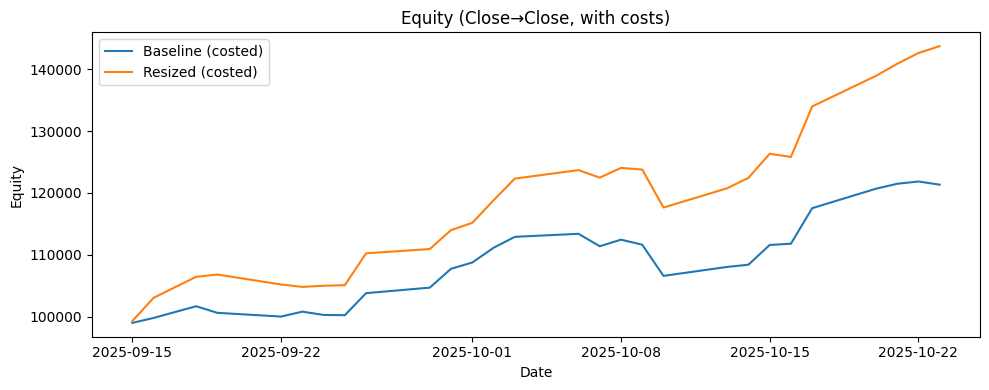

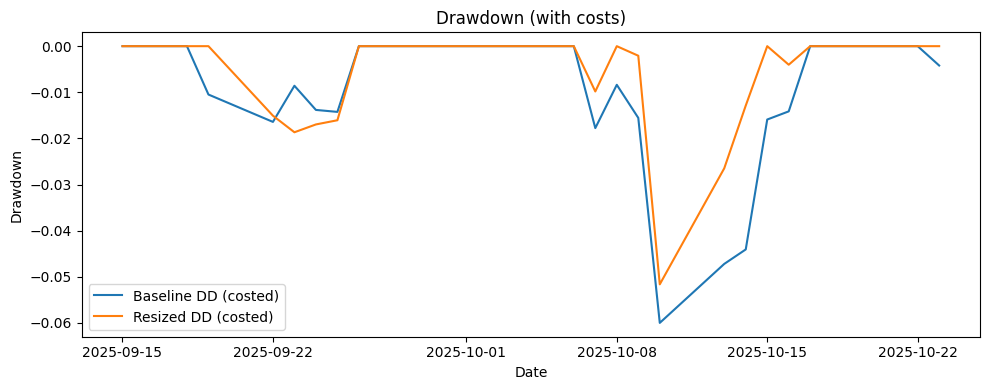

,scenario,total_return,max_drawdown,sharpe_annualized
0,baseline_costed,0.225663,-0.059998,6.047958
1,resized_costed,0.447248,-0.051640,9.325038


In [115]:
# Costed close→close equity (baseline vs resized)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Per-trade haircut: entry + exit at close →next_close
per_trade_cost = (SLIPPAGE_BPS + FEES_BPS) / 1e4
haircut = 2 * per_trade_cost

d_costed = d.copy()
borrow = np.where(d_costed[cols["side"]].eq("SELL"), SHORT_BORROW_BPS_DAILY/1e4, 0.0)
d_costed["signal_return_costed"] = np.where(
    d_costed["signal_return"].notna(),
    d_costed["signal_return"] - haircut - borrow,
    np.nan
)

def simulate_equity_with(df: pd.DataFrame, return_col: str) -> pd.DataFrame:
    tmp = df.copy()
    tmp["_pos_base"] = pd.to_numeric(tmp.get(cols["pos"], np.nan), errors="coerce").fillna(0.0)
    tmp["_pos_new"]  = pd.to_numeric(tmp.get("pos_frac_suggested", np.nan), errors="coerce").fillna(tmp["_pos_base"])
    tmp["_ret_base"] = tmp["_pos_base"] * tmp[return_col]
    tmp["_ret_new"]  = tmp["_pos_new"]  * tmp[return_col]
    daily = tmp.groupby(cols["date"]).agg(
        base_pos_sum=("_pos_base","sum"),
        new_pos_sum=("_pos_new","sum"),
        base_ret_sum=("_ret_base","sum"),
        new_ret_sum=("_ret_new","sum")
    ).reset_index()
    daily["base_ret_norm"] = daily["base_ret_sum"] / np.maximum(1.0, daily["base_pos_sum"].replace(0,1.0))
    daily["new_ret_norm"]  = daily["new_ret_sum"]  / np.maximum(1.0, daily["new_pos_sum"].replace(0,1.0))
    daily = daily.sort_values(cols["date"]).copy()
    daily["equity_base"] = START_EQUITY * (1.0 + daily["base_ret_norm"].fillna(0.0)).cumprod()
    daily["equity_new"]  = START_EQUITY * (1.0 + daily["new_ret_norm"].fillna(0.0)).cumprod()
    return daily

# Ignore unknown outcomes for the sim itself
daily_costed = simulate_equity_with(d_costed[d_costed["signal_return_costed"].notna()], "signal_return_costed")

# Stats + save
comp_costed = pd.DataFrame([
    {"scenario":"baseline_costed", **equity_stats(daily_costed["equity_base"], daily_costed["base_ret_norm"])},
    {"scenario":"resized_costed",  **equity_stats(daily_costed["equity_new"],  daily_costed["new_ret_norm"])},
])

daily_costed.to_csv(OUT_DIR/"daily_returns_equity_baseline_vs_resized_costed.csv", index=False)
comp_costed.to_csv(OUT_DIR/"equity_comparison_stats_costed.csv", index=False)

# Plots (optional)
plt.figure(figsize=(10,4))
plt.plot(daily_costed[cols["date"]], daily_costed["equity_base"], label="Baseline (costed)")
plt.plot(daily_costed[cols["date"]], daily_costed["equity_new"],  label="Resized (costed)")
plt.title("Equity (Close→Close, with costs)"); plt.xlabel("Date"); plt.ylabel("Equity")
plt.legend(); plt.tight_layout()
plt.savefig(OUT_DIR/"equity_curves_costed.png"); plt.show()

def _dd(series):
    arr = series.values
    runmax = np.maximum.accumulate(arr)
    return (arr - runmax) / runmax

plt.figure(figsize=(10,4))
plt.plot(daily_costed[cols["date"]], _dd(daily_costed["equity_base"]), label="Baseline DD (costed)")
plt.plot(daily_costed[cols["date"]], _dd(daily_costed["equity_new"]),  label="Resized DD (costed)")
plt.title("Drawdown (with costs)"); plt.xlabel("Date"); plt.ylabel("Drawdown")
plt.legend(); plt.tight_layout()
plt.savefig(OUT_DIR/"drawdown_costed.png"); plt.show()

comp_costed


In [116]:

# Keys for a robust merge (adjust if you use a different unique key)
keys = [cols["date"], cols["symbol"], cols["side"]]

# Rename the original position column for clarity
pos_orig_col = cols["pos"]
pos_new_col  = "pos_frac_new"

# Merge suggested sizing back onto the original ledger
enhanced_ledger = (
    ledger.merge(
        d[keys + ["pos_frac_suggested"]],
        on=keys,
        how="left",
        validate="m:1"  # many ledger rows per key ok; one suggestion per key
    )
    .assign(
        pos_frac_orig=lambda x: x[pos_orig_col] if pos_orig_col in x.columns else np.nan,
        pos_frac_new =lambda x: x["pos_frac_suggested"].fillna(x[pos_orig_col] if pos_orig_col in x.columns else np.nan),
        delta        =lambda x: x["pos_frac_new"] - (x[pos_orig_col] if pos_orig_col in x.columns else 0.0),
        multiplier   =lambda x: np.where(
            (pos_orig_col in x.columns) & (x[pos_orig_col] > 0),
            x["pos_frac_new"] / x[pos_orig_col],
            np.nan
        )
    )
)

# Pick a concise set of columns to view (add/remove as you like)
view_cols = [
    cols["date"], cols["symbol"], cols["side"],
    cols.get("close","close"),
    "pos_frac_orig", "pos_frac_suggested", "pos_frac_new", "delta", "multiplier"
]
view_cols = [c for c in view_cols if c in enhanced_ledger.columns]

# Save and show
OUT_DIR.mkdir(parents=True, exist_ok=True)
enhanced_path = OUT_DIR / "ledger_with_sizing_merged.csv"
enhanced_ledger.to_csv(enhanced_path, index=False)

print("Saved merged ledger →", enhanced_path)
enhanced_ledger[view_cols].head(30)


Saved merged ledger → out\ledger_with_sizing_merged.csv


,date,symbol,side,price,pos_frac_orig,pos_frac_suggested,pos_frac_new,delta,multiplier
0,2025-10-20,AAPL,SELL,262.245,0.3,0.400000,0.400000,0.100000,1.333333
1,2025-10-21,AAPL,SELL,262.730,0.2,0.400000,0.400000,0.200000,2.000000
2,2025-10-22,AAPL,SELL,256.860,0.2,0.400000,0.400000,0.200000,2.000000
3,2025-10-23,AAPL,BUY,259.990,0.4,0.400000,0.400000,0.000000,1.000000
4,2025-10-24,AAPL,SELL,262.780,0.2,0.400000,0.400000,0.200000,2.000000
5,2025-10-14,AEP,BUY,118.360,0.3,0.400000,0.400000,0.100000,1.333333
6,2025-10-15,AEP,SELL,118.720,0.4,0.400000,0.400000,0.000000,1.000000
7,2025-10-16,AEP,BUY,117.500,0.2,0.400000,0.400000,0.200000,2.000000
8,2025-10-17,AEP,BUY,117.650,0.2,0.400000,0.400000,0.200000,2.000000
9,2025-10-20,AEP,SELL,117.845,0.3,0.400000,0.400000,0.100000,1.333333


In [117]:
def color_delta(v):
    if pd.isna(v): return ""
    return "background-color: #e6ffed" if v > 0 else ("background-color: #ffecec" if v < 0 else "")

styled = (
    enhanced_ledger[view_cols]
    .style.format({
        "pos_frac_orig":"{:.2f}",
        "pos_frac_suggested":"{:.2f}",
        "pos_frac_new":"{:.2f}",
        "delta":"{:+.2f}",
        "multiplier":"{:.2f}"
    })
    .applymap(color_delta, subset=["delta"])
)
#styled


C:\Users\brobi\AppData\Local\Temp\ipykernel_15324\1256454211.py:14: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_delta, subset=["delta"])


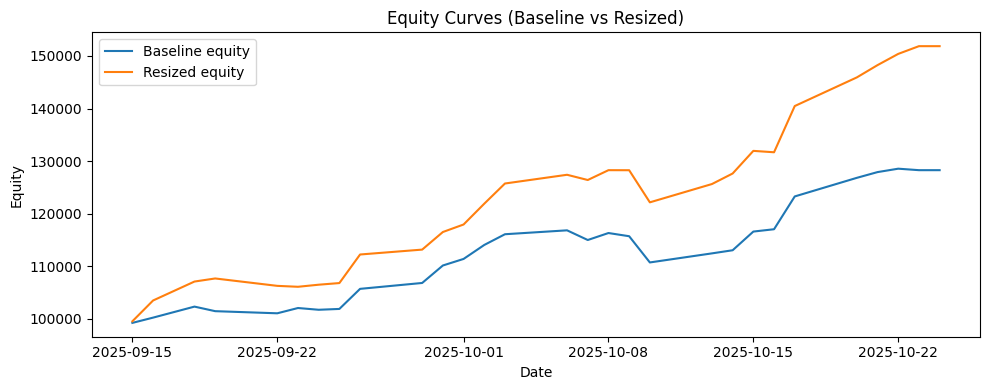

Saved: out\equity_curves_baseline_vs_resized.png


In [118]:
# Equity curve
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.plot(daily[cols["date"]], daily["equity_base"], label="Baseline equity")
plt.plot(daily[cols["date"]], daily["equity_new"],  label="Resized equity")
plt.title("Equity Curves (Baseline vs Resized)")
plt.xlabel("Date"); plt.ylabel("Equity"); plt.legend(); plt.tight_layout()
p = OUT_DIR / "equity_curves_baseline_vs_resized.png"
plt.savefig(p); plt.show()
print("Saved:", p)


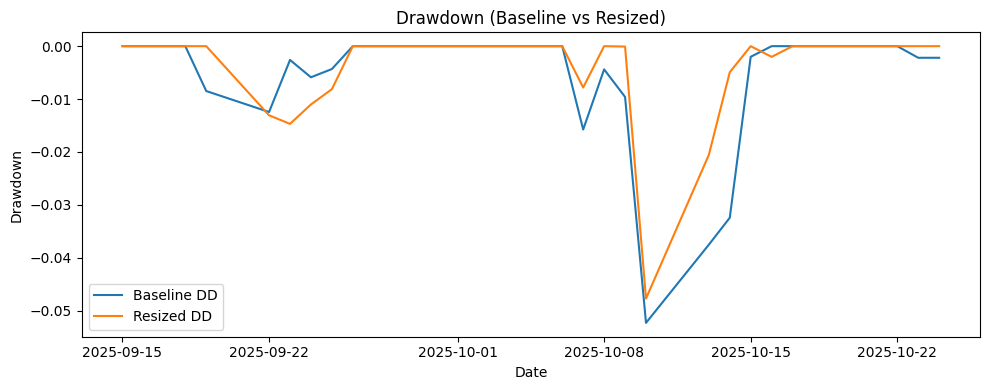

Saved: out\drawdown_baseline_vs_resized.png


In [119]:
# Drawdown
import numpy as np, matplotlib.pyplot as plt
def _dd(e):
    arr = e.values
    runmax = np.maximum.accumulate(arr)
    return (arr - runmax) / runmax

plt.figure(figsize=(10,4))
plt.plot(daily[cols["date"]], _dd(daily["equity_base"]), label="Baseline DD")
plt.plot(daily[cols["date"]], _dd(daily["equity_new"]),  label="Resized DD")
plt.title("Drawdown (Baseline vs Resized)")
plt.xlabel("Date"); plt.ylabel("Drawdown"); plt.legend(); plt.tight_layout()
p = OUT_DIR / "drawdown_baseline_vs_resized.png"
plt.savefig(p); plt.show()
print("Saved:", p)


In [120]:
# Quick causality check: current suggestion must not depend on its own outcome
ok = True
for sym, g in d.sort_values([cols["symbol"], cols["date"]]).groupby(cols["symbol"]):
    tail = []
    for i, row in g.iterrows():
        # recompute "instant" suggestion from *past* only
        mu = np.nanmean(tail[-WINDOW:]) if len(tail) else np.nan
        var = np.nanvar(tail[-WINDOW:], ddof=1) if len(tail) > 1 else np.nan
        kraw = (mu/var) if (np.isfinite(mu) and np.isfinite(var) and var > 1e-12 and mu > 0) else 0.0
        kscaled = CONSERVATIVE_SCALE * kraw
        if len(tail) >= ACCURACY_MIN_SAMPLES:
            recent_hit = np.nanmean(np.array(tail[-WINDOW:]) > 0)
            if recent_hit < 0.5: kscaled *= ACCURACY_PENALTY
        sugg_instant = float(np.clip(kscaled, MIN_FRAC, MAX_FRAC))

        # compare with what the pipeline produced
        if not np.isclose(sugg_instant, row["pos_frac_suggested"], equal_nan=True):
            ok = False
            print("Mismatch @", sym, row[cols["date"]], "instant:", sugg_instant, "pipeline:", row["pos_frac_suggested"])
            break

        # now append *after* suggestion
        if np.isfinite(row["signal_return"]):
            tail.append(float(row["signal_return"]))

print("Causality OK?", ok)

Mismatch @ AAPL 2025-10-20 00:00:00 instant: 0.1 pipeline: 0.4
Mismatch @ AEP 2025-10-14 00:00:00 instant: 0.1 pipeline: 0.4
Mismatch @ AI 2025-09-15 00:00:00 instant: 0.1 pipeline: 0.2040256100238993
Mismatch @ ALB 2025-10-22 00:00:00 instant: 0.4 pipeline: 0.1
Mismatch @ AMD 2025-09-24 00:00:00 instant: 0.4 pipeline: 0.1
Mismatch @ AMSC 2025-10-20 00:00:00 instant: 0.1 pipeline: 0.4
Mismatch @ ARQQ 2025-10-20 00:00:00 instant: 0.1 pipeline: 0.4
Mismatch @ ARRY 2025-10-20 00:00:00 instant: 0.1 pipeline: 0.4
Mismatch @ BHP 2025-10-20 00:00:00 instant: 0.1 pipeline: 0.4
Mismatch @ BYND 2025-09-15 00:00:00 instant: 0.1 pipeline: 0.4
Mismatch @ CLNE 2025-10-14 00:00:00 instant: 0.1 pipeline: 0.4
Mismatch @ COST 2025-10-20 00:00:00 instant: 0.1 pipeline: 0.4
Mismatch @ ELVA 2025-10-14 00:00:00 instant: 0.1 pipeline: 0.3632831307296798
Mismatch @ ENPH 2025-10-17 00:00:00 instant: 0.4 pipeline: 0.1
Mismatch @ ENVX 2025-10-20 00:00:00 instant: 0.1 pipeline: 0.4
Mismatch @ EOSE 2025-10-22 00:0